In [26]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad

def give_sig_weights(monopole_df):
    file = uproot.open("/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root")
    h1 = file["h1"]
    h2 = file["h2"]
    # 获取直方图的所有数据
    values = h1.values()        # bin内容（纵坐标）
    h2_values = h2.values()        # bin内容（纵坐标）
    edges = h1.axis().edges()   # bin边界（横坐标）
    h2_edges = h2.axis().edges()   # bin边界（横坐标）
    centers = h1.axis().centers()  # bin中心
    h2_centers = h2.axis().centers()  # bin中心

    values = np.array(h1.values())
    edges = np.array(h1.axis().edges())
    centers = np.array(h1.axis().centers())
    S=np.pi * 1000**2
    parker=1e-15 * 1e4 
    nums=[]
    for i, theta in enumerate(centers):
        cosine_theta = np.cos(np.deg2rad(theta))
        area = S * cosine_theta
        exposure = values[i] * area
        num_i = exposure * parker
        nums.append(num_i)

    weights=[num_i/251000/h2_values[i]/86400 for i, num_i in enumerate(nums)]
    theta_degrees = monopole_df["theta"] * 180 / np.pi
    monopole_weights = []
    for theta in theta_degrees:
        if theta > max(centers) or theta < 0:
            weight = weights[-1] if theta > max(centers) else 0
        else:
            bin_id = np.digitize(theta, edges) - 1
            weight = weights[bin_id]
        monopole_weights.append(weight)
  
    monopole_df["weight"] = np.asarray(monopole_weights)  / 0.99072616 # 0.99072616为权重修正 角度smooth 补偿
    # print(f"======> Total expected monopole events after weighting: {monopole_df['weight'].sum()} ======")
    return monopole_df



from xgboost import XGBRegressor
import xgboost as xgb
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
class EnergyReconstructor:
    def __init__(self, model_path=None, linear_params_path=None):
        self.params = {
            'n_estimators': 1000,
            'learning_rate': 0.03,
            'max_depth': 8,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'random_state': 42
        }
        self.model = xgb.XGBRegressor(**self.params)
        self.model._estimator_type = "regressor"
        self.linear_model = LinearRegression()
        
        if model_path:
            self.model.load_model(model_path)
        if linear_params_path:
            with open(linear_params_path, 'r') as f:
                p = json.load(f)
            self.linear_model.coef_     = np.array(p['coef'])
            self.linear_model.intercept_ = p['intercept']

    def load_and_preprocess(self, filepath):
        data = np.load(filepath, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        
        cols_to_numeric = ['NuW3', 'rec_theta', 'dr', 'trueE']
        for col in cols_to_numeric:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df = df[df['NuW3'] > 0].copy()
        df['log_NuW3'] = np.log10(df['NuW3'])
        
        threshold = 3.16e9
        df_low  = df[df['trueE'] <  threshold].sample(frac=0.2, random_state=42)
        df_high = df[df['trueE'] >= threshold]
        df_balanced = pd.concat([df_low, df_high], ignore_index=True)
        
        mask = (df_balanced['dr'] > 0) & \
               (df_balanced['rec_theta'] > 0) & \
               (df_balanced['rec_theta'] <= np.deg2rad(70))
        clean_df = df_balanced[mask].copy()
        
        X = clean_df[['log_NuW3', 'rec_theta']].values
        y = np.log10(clean_df['trueE'] / 1e8)
        
        return X, y, clean_df['trueE']

    def train(self, X, y,
              model_save_path   = "/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json",
              linear_save_path  = "/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json"):
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=99)
        
        # ── Step 1: 线性模型拟合全局趋势 ──────────────────────────
        print("Fitting linear baseline model...")
        self.linear_model.fit(X_train, y_train)
        
        y_linear_train = self.linear_model.predict(X_train)
        y_linear_test  = self.linear_model.predict(X_test)
        
        print(f"  Linear model coef  : log_NuW3={self.linear_model.coef_[0]:.6f}, "
              f"rec_theta={self.linear_model.coef_[1]:.6f}")
        print(f"  Linear model intercept: {self.linear_model.intercept_:.6f}")
        
        # ── Step 2: XGBoost 仅拟合残差 ────────────────────────────
        y_residual_train = y_train - y_linear_train
        
        print("Training XGBoost residual model...")
        self.model.fit(X_train, y_residual_train)
        
        # ── Step 3: 组合预测与评估 ────────────────────────────────
        y_residual_pred = self.model.predict(X_test)
        y_pred = y_linear_test + y_residual_pred        # ← 最终预测
        
        mae = mean_absolute_error(y_test, y_pred)
        r2  = r2_score(y_test, y_pred)
        
        # 与纯线性对比
        mae_lin = mean_absolute_error(y_test, y_linear_test)
        r2_lin  = r2_score(y_test, y_linear_test)
        
        print(f"\n[Pure Linear]   MAE: {mae_lin:.4f},  R²: {r2_lin:.4f}")
        print(f"[Linear + XGB]  MAE: {mae:.4f},  R²: {r2:.4f}  ← final model")
        
        # ── Step 4: 保存 ──────────────────────────────────────────
        self.model.save_model(model_save_path)
        
        linear_params = {
            "coef":      self.linear_model.coef_.tolist(),   # [coef_log_NuW3, coef_rec_theta]
            "intercept": float(self.linear_model.intercept_),
            "feature_order": ["log_NuW3", "rec_theta"]       # 备忘顺序，C++对照
        }
        with open(linear_save_path, 'w') as f:
            json.dump(linear_params, f, indent=2)
        
        print(f"\nXGBoost model  saved → {model_save_path}")
        print(f"Linear params  saved → {linear_save_path}")
        
        return X_test, y_test, y_pred

    def predict(self, X):
        """组合预测：线性外推 + XGBoost残差"""
        return self.linear_model.predict(X) + self.model.predict(X)


# --- 使用示例 ---
agent = EnergyReconstructor(model_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json", 
                          linear_params_path="/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json")



r_low=300
r_high=450
theta_low=0
theta_high=35 / 180.0 * np.pi

Eage_low=0.8
Eage_high=1.6
log10TeV_low=1.8
log10TeV_high=2.3
# rec_theta [0, 70*pi/180], Eage [0.8, 1.6], rho40 [0, 150], pincness [0.6, 1], compactness [0, 1]
rho40_low=0
rho40_high=150
pincness_low=0.6
pincness_high=1.0
compactness_low=0
compactness_high=1.0

def filter_dataset_optimized(npz_file, mc=True, is_csv=False, radius_cut=True):
    print("--------------------------------------------------")
    # param_names=["label","gaisser_weight",
    #                 "R_ue", "R_mean", "Eage",
    #                 "recE", "rec_x", "rec_y", "rec_theta", "rec_phi", 
    #                 "trueE", "NuW2", "NpE3", "NuM1", "core_x","core_y","theta"]
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    else:
        theta_low=0
        theta_high=35 / 180.0 * np.pi
    

    if not is_csv:
        data = np.load(npz_file, allow_pickle=True)
        params_df = pd.DataFrame(data["params"], columns=data["param_names"])
        del data
        
    else:
        params_df = pd.read_csv(npz_file)
        
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    rho40 = np.asarray(params_df["rho40"].values, dtype=float)
    pincness = np.asarray(params_df["pincness"].values, dtype=float)
    compactness = np.asarray(params_df["compactness"].values, dtype=float)
    
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 4. 筛选 rho40 (rho40_low < rho40 < rho40_high)
    rho40_mask = (rho40 > rho40_low) & (rho40 < rho40_high)
    n_last = current_mask.sum()
    current_mask = current_mask & rho40_mask
    n_after = current_mask.sum()
    # print(f"    4. Cut rho40: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 5. 筛选 pincness (pincness_low < pincness < pincness_high)
    pincness_mask = (pincness > pincness_low) & (pincness < pincness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & pincness_mask
    n_after = current_mask.sum()
    # print(f"    5. Cut pincness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 6. 筛选 compactness (compactness_low < compactness < compactness_high)
    compactness_mask = (compactness > compactness_low) & (compactness < compactness_high)
    n_last = current_mask.sum()
    current_mask = current_mask & compactness_mask
    n_after = current_mask.sum()
    # print(f"    6. Cut compactness: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")


    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
   
    return params_df[current_mask].copy()


# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
#        'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
#        'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat',
#        'gaisser_weight', 'horandel_weight'],
#       dtype='object')
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print("Monopole Data Processing...")
mn_npz_file =  "/data/home/zzh/data/Dataset_Filted/Monopole/filted_Monopole_1e10_merged_1000_70_dataset_muon_smooth.npz"
mn_df= filter_dataset_optimized(mn_npz_file, mc=True)
mn_df = give_sig_weights(mn_df)

mn_df_large= filter_dataset_optimized(mn_npz_file, mc=True, radius_cut=False)
mn_df_large = give_sig_weights(mn_df_large)
# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
# Exp Rue2_2
print("\nExperimental Rue1_1.9 Data (2024 361days) Processing...")
exp_muon_Rue_npz_file = "/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/1e10_V04_4Years.npz"
exp_muon_Rue_df = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=True)

exp_muon_Rue_df_large = filter_dataset_optimized(exp_muon_Rue_npz_file, mc=False, radius_cut=False)

# -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
print(f"Monopole ={mn_df['weight'].sum()}")

print("\nLarge Radius Cut:")
print(f"Monopole ={mn_df_large['weight'].sum()}, one year={mn_df_large['weight'].sum()*365*86400}")
print(f"Experimental Rue2_2 ={exp_muon_Rue_df_large['weight'].sum()}, one year={exp_muon_Rue_df_large['weight'].sum()}")


Monopole Data Processing...
--------------------------------------------------
--- 原始数据量: 103839 ---
    1. Cut r: 27930 / 103839 (Left Ratio: 26.90%)
    2. Cut theta: 10304 / 27930 (Left Ratio: 36.89%)
    0. Cut log10TeV: 10240 / 10304 (Left Ratio: 99.38%)
    3. Cut Eage: 10231 / 10240 (Left Ratio: 99.91%)
    --- 筛选结果 ---
    原始数据量: 103839
    筛选后数据量: 10231
    总通过比例: 9.85%
--------------------------------------------------
--- 原始数据量: 103839 ---
    1. Cut dr: 85248 / 103839 (Left Ratio: 82.10%)
    2. Cut theta: 85114 / 85248 (Left Ratio: 99.84%)
    0. Cut log10TeV: 82614 / 85114 (Left Ratio: 97.06%)
    3. Cut Eage: 82310 / 82614 (Left Ratio: 99.63%)
    --- 筛选结果 ---
    原始数据量: 103839
    筛选后数据量: 80573
    总通过比例: 77.59%

Experimental Rue1_1.9 Data (2024 361days) Processing...
--------------------------------------------------
--- 原始数据量: 711047 ---
    1. Cut r: 136303 / 711047 (Left Ratio: 19.17%)
    2. Cut theta: 119825 / 136303 (Left Ratio: 87.91%)
    0. Cut log10TeV: 11982

In [27]:
# recE: 1.8-2.3 R_ue<-2.5
def filter_dataset_temp(file, radius_cut=True):
    print("--------------------------------------------------")
    if radius_cut is False:
        dr_low=0
        theta_low=0
        theta_high=70 / 180.0 * np.pi
    log10TeV_low=1.8
    log10TeV_high=2.3
    

    data = np.load(file, allow_pickle=True)
    params_df = pd.DataFrame(data["params"], columns=data["param_names"])
    del data

        
    for col in params_df.columns:
        params_df[col] = pd.to_numeric(params_df[col], errors='coerce')    
    params_df['log_NuW3'] = np.log10(pd.to_numeric(params_df['NuW3'], errors='coerce'))
    params_df['recE'] = agent.predict(params_df[['log_NuW3', 'rec_theta']].values)
    initial_count = len(params_df)
    current_mask = np.ones(initial_count, dtype=bool)
    
    # asarray re ensure float dtype for calculations
    recE = np.asarray(params_df["recE"].values, dtype=float)
    R_ue = np.asarray(params_df["R_ue"].values, dtype=float)
    R_mean = np.asarray(params_df["R_mean"].values, dtype=float)
    Eage = np.asarray(params_df["Eage"].values, dtype=float)
    rec_theta = np.asarray(params_df["rec_theta"].values, dtype=float)
    rec_phi = np.asarray(params_df["rec_phi"].values, dtype=float)
    rec_x = np.asarray(params_df["rec_x"].values, dtype=float)
    rec_y = np.asarray(params_df["rec_y"].values, dtype=float)
    r = np.sqrt(rec_x**2 + rec_y**2)    
    dr = np.asarray(params_df["dr"].values, dtype=float)
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    # 顺序筛选与打印比例
    # -------------------------------------------------- --------------------------------------------------  --------------------------------------------------
    print(f"--- 原始数据量: {initial_count} ---")
    

    # 1. 筛选 r (r_low < r < r_high)
    if radius_cut is False:
        r_mask = (dr > dr_low)
        # r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut dr: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    elif radius_cut is True:
        r_mask = (r > r_low) & (r < r_high)
        n_last = current_mask.sum()
        current_mask = current_mask & r_mask
        n_after = current_mask.sum()
        print(f"    1. Cut r: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 2. 筛选 theta (theta_low < theta < theta_high)
    theta_mask = (rec_theta > theta_low) & (rec_theta < theta_high)
    n_last = current_mask.sum()
    current_mask = current_mask & theta_mask
    n_after = current_mask.sum()
    print(f"    2. Cut theta: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")

    # 0. 筛选 log10TeV (log10TeV_low < recE < log10TeV_high)
    log10TeV_mask = (recE > log10TeV_low) & (recE < log10TeV_high)
    n_last = current_mask.sum()
    current_mask = current_mask & log10TeV_mask
    n_after = current_mask.sum()
    print(f"    0. Cut log10TeV: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    # 2. 筛选 Eage (Eage_low < Eage < Eage_high)
    Eage_mask = (Eage > Eage_low) & (Eage < Eage_high)
    n_last = current_mask.sum()
    current_mask = current_mask & Eage_mask
    n_after = current_mask.sum()
    print(f"    3. Cut Eage: {n_after} / {n_last} (Left Ratio: {n_after/n_last:.2%})")
    
    
    # 打印最终统计信息
    final_count = current_mask.sum()
    print(f"    --- 筛选结果 ---")
    print(f"    原始数据量: {initial_count}")
    print(f"    筛选后数据量: {final_count}")
    print(f"    总通过比例: {final_count/initial_count:.2%}")
   
    return params_df[current_mask].copy()



exp_temp_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/temp_15Days_DataDriven_20230101-15_1e10_V04.npz"
exp_temp_df = filter_dataset_temp(exp_temp_file, radius_cut=False)
exp_temp_df['weight_norm'] = 1 * 365/15 # I scale to one year
SR_Rue_cut=-2.85
SR_recE_low = 1.95
SR_recE_high = 2.1
exp_temp_df_CR = exp_temp_df[exp_temp_df['R_ue'] > SR_Rue_cut]
exp_temp_df_SR = exp_temp_df[exp_temp_df['R_ue'] < SR_Rue_cut]
exp_temp_df_CRrecE = exp_temp_df[(exp_temp_df['recE'] > SR_recE_low) & (exp_temp_df['recE'] < SR_recE_high)]
print(exp_temp_df.columns)
# Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
#        'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE1',
#        'NpE2', 'NpE3', 'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE',
#        'core_x', 'core_y', 'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd',
#        'tlong', 'tlat', 'log_NuW3'],
#       dtype='object')

# Description:
# features for MLP : rec_theta, Eage, rho40, pincness, compactness
# this dataset' Rue range is about less than -1.5, the Signal Region cut of R_ue is less than -2.85
# what i want to do is to use this dataset to validate an assumption of with the decreasing of R_ue cut threshold
# the distribution of these features will be more and more stable,
# so I can use the distribution of these features in this dataset to represent the distribution of these features in the signal region (R_ue < -2.85) for the background,
# and then use that to train the MLP to distinguish signal and background in the signal region.
# and for systematic uncertainty estimation, I use the variation of R_ue cut to represent, the little difference of features distribution will be use as intput of MLP to 
# quantify the histogram variation.
# what you do is :
# 1. plot the distribution of these features with different R_ue cut threshold, like -1.5, -2.0, -2.5, -2.85, and see how the distribution change with the decreasing of R_ue cut threshold.(In a big figure with reasonable layout)
# 2. in R_ue distribution in log scale, use linear fit to get the total yield in SR (sideband fit), get the value and uncertainty of the extrapolation
# 3. find a reasonable R_ue cut as my template in SR (you first do 1 and 2, this remain to the end, after we confirm the result of 1 and 2)

--------------------------------------------------
--- 原始数据量: 1274624 ---
    1. Cut dr: 1274624 / 1274624 (Left Ratio: 100.00%)
    2. Cut theta: 1274622 / 1274624 (Left Ratio: 100.00%)
    0. Cut log10TeV: 1274622 / 1274622 (Left Ratio: 100.00%)
    3. Cut Eage: 1273716 / 1274622 (Left Ratio: 99.93%)
    --- 筛选结果 ---
    原始数据量: 1274624
    筛选后数据量: 1273716
    总通过比例: 99.93%
Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
       'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE1',
       'NpE2', 'NpE3', 'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE',
       'core_x', 'core_y', 'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd',
       'tlong', 'tlat', 'log_NuW3', 'weight_norm'],
      dtype='object')


In [123]:
# exp_temp_df_CRrecE[(exp_temp_df_CRrecE['R_ue']<-5)]['weight_norm'].sum()
len(exp_muon_Rue_df[(exp_muon_Rue_df['R_ue']<-2.85) & (exp_muon_Rue_df['recE']>1.95) & (exp_muon_Rue_df['recE']<2.1)])
len(exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue']<-2.7) & (exp_muon_Rue_df_large['recE']>1.95) & (exp_muon_Rue_df_large['recE']<2.1)])

18033

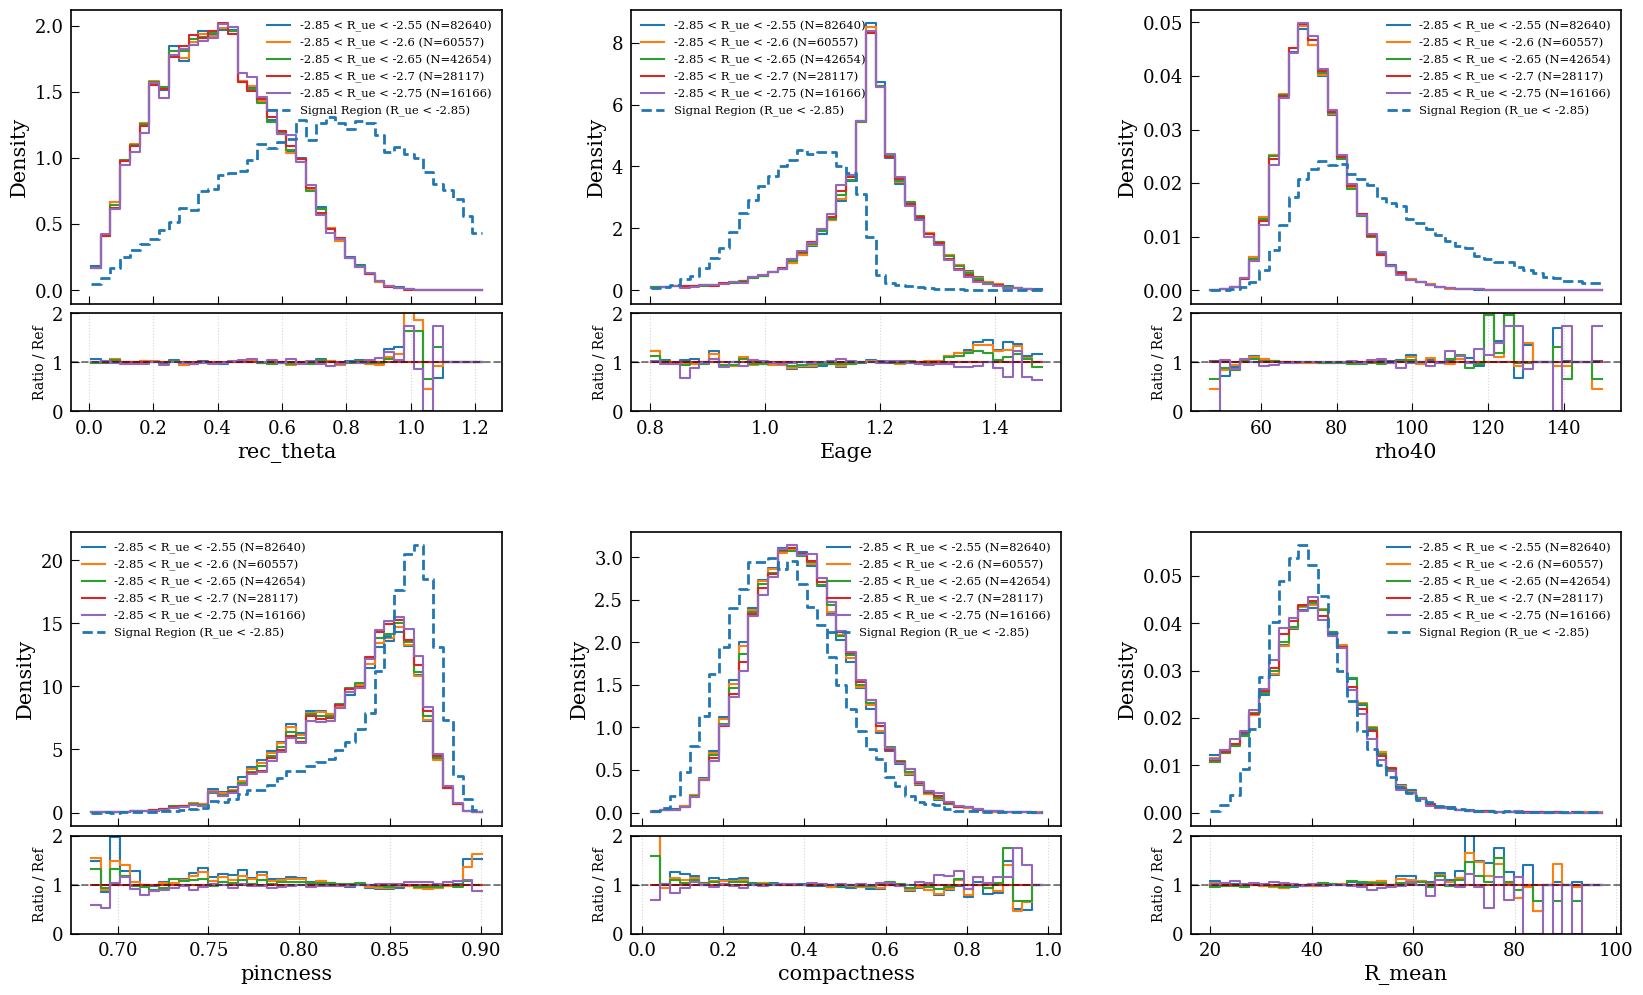

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.gridspec as gridspec

def plot_stability_with_ratio(df, sideband_thresholds=[-2.55, -2.6, -2.65, -2.7, -2.75, ], 
                              SR_limit=-2.85, reference_thresh=-2.7):
    features = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean']
    
    # 创建画布
    fig = plt.figure(figsize=(20, 12))
    # 定义 2行 3列 的大网格
    outer_grid = gridspec.GridSpec(2, 3, fig, wspace=0.3, hspace=0.3)
    
    colors = sns.color_palette("tab10", len(sideband_thresholds))
    
    # 参考区间的 Mask (Nominal)
    ref_mask = (df['R_ue'] <= reference_thresh) & (df['R_ue'] > SR_limit)
    
    for i, col in enumerate(features):
        # 在每个大网格里切分出上下两个子图，高度比为 3:1
        inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[i], 
                                                      height_ratios=[3, 1], hspace=0.05)
        
        ax_main = plt.Subplot(fig, inner_grid[0])
        ax_ratio = plt.Subplot(fig, inner_grid[1], sharex=ax_main)
        fig.add_subplot(ax_main)
        fig.add_subplot(ax_ratio)
        
        # --- 准备基准数据 (Reference) ---
        data_ref = df[ref_mask][col].dropna()
        # 统一使用 40 个 bin
        counts_sig, bin_edges = np.histogram(sig_SR_df[col].dropna(), bins=40, density=True)
        
        counts_ref, _ = np.histogram(data_ref, bins=bin_edges, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- 循环绘制不同 Threshold ---
        for j, thresh in enumerate(sideband_thresholds):
            mask_sub = (df['R_ue'] <= thresh) & (df['R_ue'] > SR_limit)
            data_sub = df[mask_sub][col].dropna()
            
            if len(data_sub) < 10: continue
            
            # 计算直方图
            counts_sub, _ = np.histogram(data_sub, bins=bin_edges, density=True)
            
            # 1. 上方主图: Density
            ax_main.step(bin_edges, np.append(counts_sub, counts_sub[-1]), where='post', 
                         color=colors[j], lw=1.5, label=f"{SR_limit} < R_ue < {thresh} (N={len(data_sub)})")
            
            # 2. 下方副图: Ratio
            # 处理除零
            ratio = np.divide(counts_sub, counts_ref, out=np.ones_like(counts_sub), where=counts_ref!=0)
            ax_ratio.step(bin_edges, np.append(ratio, ratio[-1]), where='post', color=colors[j], lw=1.5)
            
            # # 统计误差带 (Poisson)
            # rel_err = np.sqrt(1/len(data_sub) + 1/len(data_ref)) if (len(data_sub)>0 and len(data_ref)>0) else 0
            # ax_ratio.fill_between(bin_centers, ratio*(1-rel_err), ratio*(1+rel_err), color=colors[j], alpha=0.1)

        # --- 图表装饰 ---
        # 主图
        # ax_main.set_title(f"Stability & Ratio: {col}", fontsize=14, fontweight='bold')
        ax_main.step(bin_edges, np.append(counts_sig, counts_sig[-1]), where='post', lw=2, label=f"Signal Region (R_ue < {SR_Rue_cut})", linestyle='--')
        ax_main.set_ylabel("Density")
        ax_main.legend(fontsize='x-small', loc='best', frameon=False)
        plt.setp(ax_main.get_xticklabels(), visible=False) # 隐藏主图 X 轴刻度
        
        # 副图
        ax_ratio.axhline(1.0, color='black', linestyle='--', alpha=0.5)
        ax_ratio.set_ylim(0., 2) # Ratio 范围设定
        ax_ratio.set_ylabel("Ratio / Ref", fontsize=10)
        ax_ratio.set_xlabel(col)
        ax_ratio.grid(True, which='both', linestyle=':', alpha=0.5)

    # 移除最后一个空白子图
    # fig.delaxes(fig.axes[-1])
    # fig.delaxes(fig.axes[-1]) 
    
    # plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Rue_cut_stability.pdf", dpi=300)
    plt.show()

# 调用
sig_SR_df = mn_df_large[(mn_df_large['R_ue']<SR_Rue_cut) & (mn_df_large['recE']>SR_recE_low) & (mn_df_large['recE']<SR_recE_high)]
exp_muon_Rue_df_large_recE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > SR_recE_low) & (exp_muon_Rue_df_large['recE'] < SR_recE_high)]
plot_stability_with_ratio(exp_muon_Rue_df_large_recE)


10341.666666666666


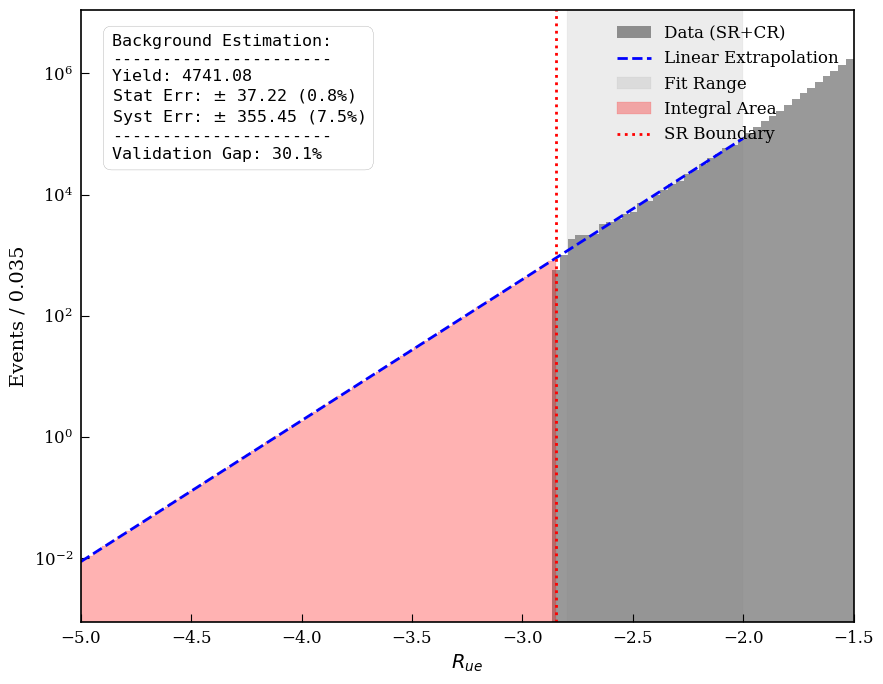

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calculate_yield(cutoff, a, b, lower_bound=-5.0):
    """解析法计算有限区间 [-5.0, cutoff] 内的积分产额"""
    return (10**(a * cutoff + b) - 10**(a * lower_bound + b)) / (a * np.log(10))

def perform_fit_and_errors(df, sr_threshold=-2.85, fit_range=(-2.85, -2.2), bins=200, lower_bound=-5.0):
    """核心拟合与误差计算模块"""
    # 强制转换为 float 避免 object 数组带来的坑
    counts, bin_edges = np.histogram(df['R_ue'], bins=bins, range=(lower_bound, -1.5), weights=df['weight_norm'])
    counts = counts.astype(float) 
    
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 过滤拟合区间并剔除 0 计数以避免 log(0)
    fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1]) & (counts > 0)
    x_fit = bin_centers[fit_mask]
    y_fit = np.log10(counts[fit_mask] / bin_width)
    y_err = 1.0 / (np.sqrt(counts[fit_mask]) * np.log(10)) 

    def linear_func(x, a_val, b_val): 
        return a_val * x + b_val
    
    popt, pcov = curve_fit(linear_func, x_fit, y_fit, sigma=y_err, absolute_sigma=True)
    central_yield = calculate_yield(sr_threshold, *popt, lower_bound=lower_bound)
    
    # --- 统计误差 (Multivariate Normal Sampling) ---
    samples = np.random.multivariate_normal(popt, pcov, 2000)
    stats_yields = [calculate_yield(sr_threshold, s[0], s[1], lower_bound) for s in samples]
    stat_err = np.std(stats_yields)

    # --- 系统误差 (Fit Range Variation) ---
    size_x = len(x_fit)
    size_shift = max(1, int(size_x * 0.2)) # 至少移动 1 个 bin
    
    # 左移/右移拟合区间进行稳定性测试
    popt_var1, _ = curve_fit(linear_func, x_fit[:-size_shift], y_fit[:-size_shift], sigma=y_err[:-size_shift])
    popt_var2, _ = curve_fit(linear_func, x_fit[size_shift:], y_fit[size_shift:], sigma=y_err[size_shift:])
    
    yield_var1 = calculate_yield(sr_threshold, *popt_var1, lower_bound)
    yield_var2 = calculate_yield(sr_threshold, *popt_var2, lower_bound)
    syst_err = np.abs(yield_var1 - yield_var2) / 2.0
    
    return central_yield, stat_err, syst_err, popt, bin_width

def plot_refined_sideband(df_main, df_val, sr_threshold=-2.85, fit_range=(-2.85, -2.2), bins=200, lower_bound=-5.0):
    """集成计算、验证与绘图的完整分析函数"""
    
    # 1. 计算主信号区产额及误差
    sr_yield, sr_stat, sr_syst, popt, bin_width = perform_fit_and_errors(
        df_main, sr_threshold, fit_range, bins, lower_bound
    )
    
    # 2. 计算验证区 (Validation Region) 的 Gap
    # 实际产额
    val_actual = df_val[(df_val['R_ue'] < sr_threshold) & (df_val['R_ue'] > lower_bound)]['weight_norm'].sum()
    # 拟合外推产额
    val_pred, _, _, _, _ = perform_fit_and_errors(
        df_val, sr_threshold, fit_range, bins, lower_bound
    )
    val_gap = np.abs(val_pred - val_actual) / val_pred if val_pred > 0 else 0

    # 3. 开始绘图 (仅使用 R_ue > -5 的数据)
    df_plot = df_main[(df_main['R_ue'] > lower_bound) & (df_main['R_ue'] < -1.5)]
    
    fig, ax = plt.subplots(figsize=(9, 7))
    
    # 画数据直方图
    counts, bin_edges, _ = ax.hist(df_plot[df_plot['R_ue']>SR_Rue_cut]['R_ue'], bins=bins, range=(lower_bound, -1.5), 
                                   weights=df_plot[df_plot['R_ue']>SR_Rue_cut]['weight_norm'], color='black', alpha=0.4, 
                                   histtype='stepfilled', label='Data (SR+CR)')
    
    # 画拟合延伸线
    x_line = np.linspace(lower_bound, fit_range[1], 200)
    y_line = 10**(popt[0] * x_line + popt[1]) * bin_width
    ax.plot(x_line, y_line, color='blue', linestyle='--', linewidth=2, label='Linear Extrapolation')
    
    # 【新增】画拟合区间的背景阴影带
    ax.axvspan(fit_range[0], fit_range[1], color='gray', alpha=0.15, label='Fit Range')
    
    # 【新增】画积分区域的填充 (从 lower_bound 到 cut)
    x_fill = np.linspace(lower_bound, sr_threshold, 100)
    y_fill = 10**(popt[0] * x_fill + popt[1]) * bin_width
    # y2 参数设为一个极小值，以在 Log 坐标轴下正确向下填充
    ax.fill_between(x_fill, 1e-10, y_fill, color='red', alpha=0.3, step='mid', label='Integral Area')
    
    # 分界线
    ax.axvline(sr_threshold, color='red', linestyle=':', linewidth=2, label='SR Boundary')
    
    # 图表修饰
    ax.set_yscale('log')
    # 根据实际数据的量级动态调整 Y 轴底线，防止由于极小值导致画面比例失调
    ax.set_ylim(bottom=max(1e-4, (10**(popt[0] * lower_bound + popt[1]) * bin_width) * 0.1))
    ax.set_xlim(lower_bound, -1.5)
    
    ax.set_xlabel(r'$R_{ue}$', fontsize=14)
    ax.set_ylabel(f'Events / {(bin_edges[1]-bin_edges[0]):.3f}', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.legend(loc='upper right', frameon=False, fontsize=12)
    
    # 【新增】将计算结果作为内嵌文字展示，而不是 Title
    text_info = (
        f"Background Estimation:\n"
        f"----------------------\n"
        f"Yield: {sr_yield:.2f}\n"
        f"Stat Err: $\pm$ {sr_stat:.2f} ({(sr_stat/sr_yield):.1%})\n"
        f"Syst Err: $\pm$ {sr_syst:.2f} ({(sr_syst/sr_yield):.1%})\n"
        f"----------------------\n"
        f"Validation Gap: {val_gap:.1%}"
    )
    
    # 放置在图表左上角
    props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.04, 0.96, text_info, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=props, fontfamily='monospace')
    
    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Rue_cut_sideband_fit_less_muon.pdf", dpi=300)
    plt.show()
    
    return sr_yield, sr_stat, sr_syst, val_gap

# ================= 调用部分 =================

# 设定物理边界参数
SR_RUE_CUT = -2.85
FIT_RANGE = (-2.8, -2)
LOWER_BOUND = -5.0

# 提取 Validation 区间数据
exp_temp_df_CRrecE_lowE = exp_temp_df[(exp_temp_df['recE'] > 1.8) & (exp_temp_df['recE'] < 1.95)]
print(exp_temp_df_CRrecE_lowE[(exp_temp_df_CRrecE_lowE['R_ue'] < SR_RUE_CUT) & (exp_temp_df_CRrecE_lowE['R_ue'] > LOWER_BOUND)]['weight_norm'].sum())
# exp_muon_Rue_df_large['weight_norm'] = exp_muon_Rue_df_large['weight']
# exp_temp_df_CRrecE_lowE = exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > 1.9) & (exp_muon_Rue_df_large['recE'] < 1.95)]
# 执行完整流程并绘图
sr_yield, sr_stat, sr_syst, val_gap = plot_refined_sideband(
    df_main=exp_temp_df_CRrecE, 
    df_val=exp_temp_df_CRrecE_lowE,
    sr_threshold=SR_RUE_CUT, 
    fit_range=FIT_RANGE, 
    bins=100, 
    lower_bound=LOWER_BOUND
)

N_lessMuon = sr_yield
# plot_refined_sideband(
#     df_main=exp_temp_df_CRrecE_lowE, 
#     df_val=exp_temp_df_CRrecE_lowE,
#     sr_threshold=SR_RUE_CUT, 
#     fit_range=FIT_RANGE, 
#     bins=100, 
#     lower_bound=LOWER_BOUND
# )

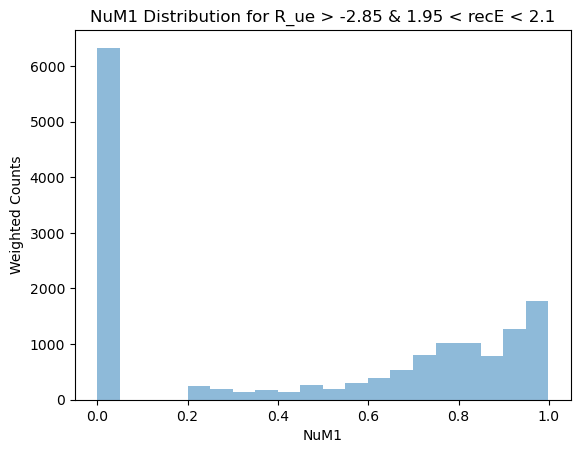

In [36]:
NuM1=exp_temp_df_CRrecE['NuM1'].values
NuM1_0_1 = NuM1[NuM1<1]
plt.hist(NuM1_0_1, bins=20, weights=exp_temp_df_CRrecE[NuM1<1]['weight_norm'], alpha=0.5)
plt.xlabel("NuM1")
plt.ylabel("Weighted Counts")
plt.title("NuM1 Distribution for R_ue > -2.85 & 1.95 < recE < 2.1")
plt.show()



In [10]:

from scipy.stats import moyal
from scipy.optimize import curve_fit
from scipy.stats import lognorm
import scipy.integrate as integrate


def extrapolate_zero_muon_yield(df, sr_threshold=-2.85, fit_range=(0.2, 50),integral_range=(0,1), bins=30, plot=False):
    # 1. 划定 Control Region (CR) 并计算总权重
    cr_mask = (df['R_ue'] > sr_threshold) & (df['NuM1'] >= fit_range[0]) & (df['NuM1'] <= fit_range[1])
    df_cr = df[cr_mask]
    total_weight = df_cr['weight_norm'].sum() # 关键：用于最后的 scale
    
    if total_weight == 0:
        return 0.0, 0.0

    # 2. 提取归一化密度直方图 (density=True)
    # 此时 counts 代表的是 dP/dx，即单位 x 的概率
    counts, bin_edges = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, 
                                     weights=df_cr['weight_norm'], density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 计算密度的误差 (Propagation of errors for normalized density)
    # Error(Density) = sqrt(sum(w^2)) / (Total_Weight * bin_width)
    counts_sq, _ = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight_norm']**2)
    y_err = np.sqrt(counts_sq) / (total_weight * bin_width)
    
    valid_mask = (counts > 0)
    x_fit = bin_centers[valid_mask]
    y_fit = counts[valid_mask]

    # 3. 定义拟合函数 (作为 PDF 的幅值修正)
    def lognorm_pdf(x, amplitude, s, loc, scale):
        return amplitude * lognorm.pdf(x, s=s, loc=loc, scale=scale)

    # 初始猜测：因为是 density=True，amplitude 应该在 1 附近
    peak_idx = np.argmax(y_fit)
    p0 = [1.0, 0.7, 0, x_fit[peak_idx]]
    
    # 4. 执行曲线拟合
    try:
        popt, pcov = curve_fit(lognorm_pdf, x_fit, y_fit, p0=p0, sigma=y_err, 
                               absolute_sigma=True, maxfev=20000)
    except RuntimeError:
        print("Fit failed.")
        return 0.0, 0.0
    
    # 5. 积分计算概率 P(0 < NuM1 < 0.2)
    prob_extrap, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(popt))
    
    # 6. 最终结果：概率 * 总权重
    yield_extrap = prob_extrap * total_weight
    
    # 7. 误差传播 (蒙特卡洛采样)
    samples = np.random.multivariate_normal(popt, pcov, 1000)
    integrals = []
    for samp in samples:
        try:
            if samp[1] <= 0 or samp[3] <= 0: continue 
            val, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(samp))
            integrals.append(val * total_weight)
        except:
            continue
    yield_extrap_err = np.std(integrals) if len(integrals) > 0 else 0.0

    if plot:
        plt.figure(figsize=(10, 6))
        # 此时 y 轴是 Density (Probability per unit x)
        plt.errorbar(x_fit, y_fit, yerr=y_err, fmt='ko', label='Normalized CR Data', markersize=5)
        
        x_plot = np.linspace(0, fit_range[1], 1000)
        y_plot = lognorm_pdf(x_plot, *popt)
        plt.plot(x_plot, y_plot, 'r-', linewidth=2, label=f'Log-normal PDF Fit')
        
        plt.yscale('log')
        plt.title(f"Density Fit & Scale: Final Yield = {yield_extrap:.2f}")
        plt.xlabel("NuM1")
        plt.ylabel("Probability Density ($dP/dx$)")
        plt.legend()
        plt.grid(True, which="both", ls="--", alpha=0.4)
        plt.show()

    return yield_extrap, yield_extrap_err
extrap_yield_list = []
extrap_err_list = []
Rue_cut_values = np.linspace(-2.7, -2.85, 25)  # 从 -2.6 到 -2.85，25 个点
for i, Rue_cut in enumerate(Rue_cut_values):
    plot=False
    if i == 0 or i==5:
        plot = True
    else:        plot = False
    extrap_yield, extrap_err = extrapolate_zero_muon_yield(exp_temp_df_CRrecE_low, sr_threshold=Rue_cut, plot=plot)
    extrap_yield_list.append(extrap_yield)
    extrap_err_list.append(extrap_err)
    print(f"when use R_ue > {Rue_cut:.2f} data, 通过 CR 拟合外推得到的 NuM1=0 预期背景数: {extrap_yield:.2f} ± {extrap_err:.2f}")
    
# plt.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, fmt='o-', color='blue')
# plt.xlabel("R_ue Cut for CR")
# plt.ylabel("Extrapolated Yield at NuM1=0")
# plt.title("Extrapolated Zero-Muon Yield vs R_ue Cut")
# plt.grid(True, ls="--", alpha=0.5)
# plt.show()

from scipy.optimize import curve_fit

# 1. 定义函数：A 是我们要找的极限（平台），B*exp(Cx) 是偏离项
def plateau_func(x, A, B, C):
    return A - B * np.exp(C * x)

# 2. 更加物理的初始值猜测 (Initial Guess)
# A 应该比现在的最大值（约640）稍大一点
y_max = np.max(extrap_yield_list)
y_min = np.min(extrap_yield_list)
p0_A = y_max * 1.1 

# 粗略估算 C。假设 y1 = A - B*exp(Cx1), y2 = A - B*exp(Cx2)
# 取首尾两点通过变化率估算 C 约为 5~10 左右
p0_C = 5.0 

# 推导 B：B = (A - y_min) / exp(C * x_min)
p0_B = (p0_A - y_min) / np.exp(p0_C * Rue_cut_values[0])

# 3. 执行带边界的拟合
# Bounds: A > y_max, B > 0, C > 0
try:
    popt, pcov = curve_fit(
        plateau_func, 
        Rue_cut_values, 
        extrap_yield_list, 
        p0=[p0_A, p0_B, p0_C],
        sigma=extrap_err_list,        # 加入权重
        absolute_sigma=True,
        bounds=([y_max, 0, 0], [y_max*5, np.inf, 20]), # 设定合理边界
        maxfev=100000
    )
    print(f"Fitted parameters: A={popt[0]:.2f}, B={popt[1]:.2f}, C={popt[2]:.2f}")
    print(f"covariance matrix:\n{pcov}")
    perr = np.sqrt(np.diag(pcov))
    print(f"预测的极限平台 Yield (A): {popt[0]:.2f} ± {perr[0]:.2f}")
    
except Exception as e:
    print(f"拟合再次失败: {e}")
    popt = [p0_A, p0_B, p0_C] # 失败则回退


Plateau_Yield = popt[0]
# 4. 绘图
# plt.figure(figsize=(10, 8))
x_plot = np.linspace(Rue_cut_values[0], -3.1, 100)
y_plot = plateau_func(x_plot, *popt)

plt.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, 
             fmt='o', color='blue', markersize=4, label='Data (Extrapolated)')
plt.plot(x_plot, y_plot, 'r-', lw=2, label=f'Plateau Fit: $A={popt[0]:.2f}$')
plt.axhline(popt[0], color='gray', linestyle='--', alpha=0.5, label='Asymptotic Limit')

plt.xlabel(r"$R_{ue}$ Cut for CR", fontsize=14)
plt.ylabel("Extrapolated Yield at $NuM1=0$", fontsize=14)
plt.title("Plateau Fit for Background Normalization", fontsize=15)
plt.grid(True, ls="--", alpha=0.3)
plt.legend()
plt.show()

# 在你原有 Plateau Fit 基础上增加
# A 是平台值，perr[0] 是其统计拟合误差
Plateau_Yield_central = popt[0]
Plateau_Stat_Err = perr[0]

# --- 系统误差：稳定性误差 (Stability Uncertainty) ---
# 计算所有外推点相对于最终 A 值的残差平方根，作为形状不稳定性误差
residuals = np.array(extrap_yield_list) - Plateau_Yield_central
# 我们只关注靠近平台区（左侧）的点
stability_syst = np.std(np.array(extrap_yield_list)[Rue_cut_values < -2.75])


# --- 总误差汇总 ---
print(f"Zero-Muon 组件: {Plateau_Yield_central:.2f} ± {Plateau_Stat_Err:.2f} (Stat) ± {stability_syst:.2f} (Syst)")

NameError: name 'exp_temp_df_CRrecE_low' is not defined

>>> 开始扫描 R_ue 切迹并外推 Zero-Muon 产额...
actual 19674

>>> 最终 Zero-Muon 产额评估 (A): 2288.58 ± 102.53 (Stat) ± 32.08 (Syst)


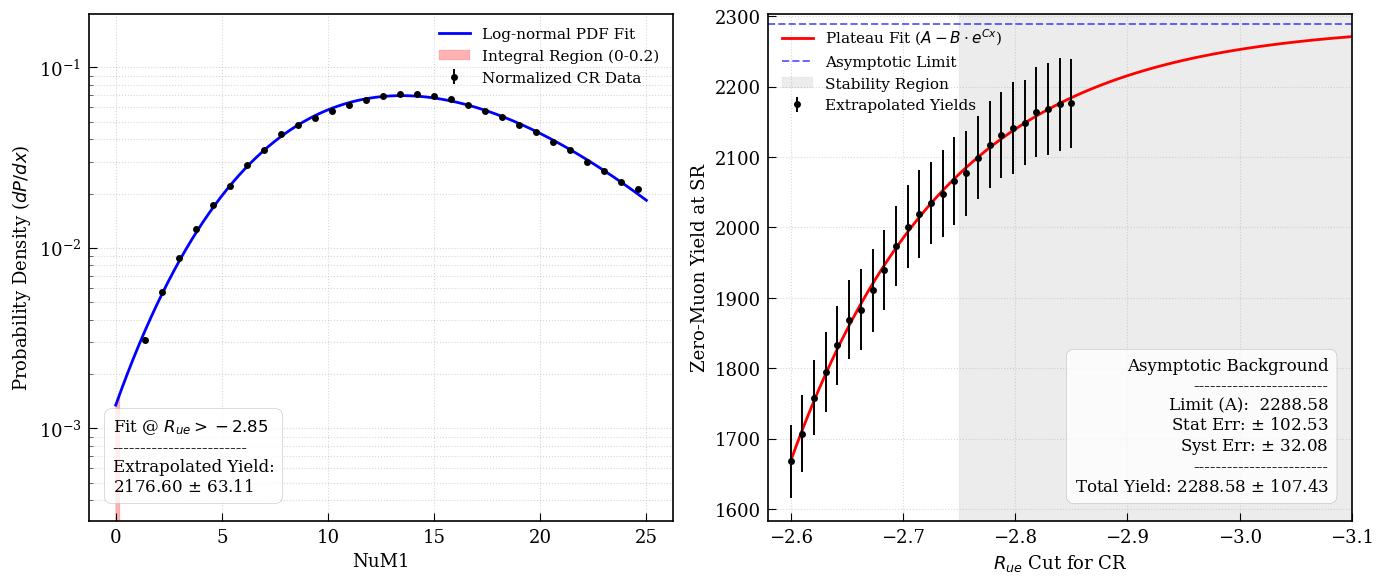

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import curve_fit
import scipy.integrate as integrate

# ====================================================================
# 核心函数定义
# ====================================================================

def lognorm_pdf(x, amplitude, s, loc, scale):
    """带幅值的对数正态分布 PDF"""
    return amplitude * lognorm.pdf(x, s=s, loc=loc, scale=scale)

def plateau_func(x, A, B, C):
    """背景极限外推公式"""
    return A - B * np.exp(C * x)

def extrapolate_zero_muon_yield(df, sr_threshold=-2.85, fit_range=(1, 25), integral_range=(0, 0.2), bins=30):
    """单个 R_ue 切迹下的 NuM1 拟合与积分外推"""
    cr_mask = (df['R_ue'] > sr_threshold) & (df['NuM1'] >= fit_range[0]) & (df['NuM1'] <= fit_range[1])
    df_cr = df[cr_mask]
    total_weight = df_cr['weight_norm'].sum()
    
    if total_weight == 0:
        return 0.0, 0.0, None

    # 计算 Density Histogram
    counts, bin_edges = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, 
                                     weights=df_cr['weight_norm'], density=True)
    counts = counts.astype(float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 计算密度误差 (Error = sqrt(sum(w^2)) / (Total_Weight * bin_width))
    counts_sq, _ = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight_norm']**2)
    y_err = np.sqrt(counts_sq.astype(float)) / (total_weight * bin_width)
    
    valid_mask = (counts > 0)
    x_fit = bin_centers[valid_mask]
    y_fit = counts[valid_mask]
    y_err_fit = y_err[valid_mask]

    # 初始猜测与拟合
    peak_idx = np.argmax(y_fit)
    p0 = [1.0, 0.7, 0, x_fit[peak_idx]]
    
    try:
        popt, pcov = curve_fit(lognorm_pdf, x_fit, y_fit, p0=p0, sigma=y_err_fit, 
                               absolute_sigma=True, maxfev=20000)
    except RuntimeError:
        return 0.0, 0.0, None
    
    # 积分与权重缩放
    prob_extrap, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(popt))
    yield_extrap = prob_extrap * total_weight
    
    # 蒙特卡洛误差采样
    samples = np.random.multivariate_normal(popt, pcov, 1000)
    integrals = []
    for samp in samples:
        try:
            if samp[1] <= 0 or samp[3] <= 0: continue 
            val, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(samp))
            integrals.append(val * total_weight)
        except:
            continue
            
    yield_extrap_err = np.std(integrals) if len(integrals) > 0 else 0.0

    # 打包用于绘图的数据
    plot_data = {
        'x_fit': x_fit, 'y_fit': y_fit, 'y_err': y_err_fit, 'popt': popt,
        'fit_range': fit_range, 'integral_range': integral_range, 'total_weight': total_weight
    }
    
    return yield_extrap, yield_extrap_err, plot_data

# ====================================================================
# 1. 扫描计算 (Scan Compute)
# ====================================================================

Rue_cut_values = np.linspace(-2.6, -2.85, 25)
extrap_yield_list = []
extrap_err_list = []

# 用于保存最具代表性的一组拟合数据（通常选取贴近 SR 的点，比如最严格切迹）
representative_cut = -2.85 
rep_plot_data = None
rep_yield = 0.0
rep_err = 0.0

print(">>> 开始扫描 R_ue 切迹并外推 Zero-Muon 产额...")
exp_SR=exp_muon_Rue_df_large[(exp_muon_Rue_df_large['R_ue'] < -2.85) 
                             & (exp_muon_Rue_df_large['recE'] > 1.95) & (exp_muon_Rue_df_large['recE'] < 2.1)]
print(f"actual {len(exp_SR[exp_SR['R_ue']>-5])}")
for cut in Rue_cut_values:
    y_extrap, y_err, p_data = extrapolate_zero_muon_yield(exp_temp_df_CRrecE, sr_threshold=cut)
    extrap_yield_list.append(y_extrap)
    extrap_err_list.append(y_err)
    
    # 保存 -2.85 (最紧切迹) 的拟合状态用于展示
    if np.isclose(cut, representative_cut) and p_data is not None:
        rep_plot_data = p_data
        rep_yield = y_extrap
        rep_err = y_err

# ====================================================================
# 2. 极限平台拟合 (Plateau Fit)
# ====================================================================

y_max, y_min = np.max(extrap_yield_list), np.min(extrap_yield_list)
p0_A = y_max * 1.1 
p0_C = 5.0 
p0_B = (p0_A - y_min) / np.exp(p0_C * Rue_cut_values[0])

try:
    popt_plat, pcov_plat = curve_fit(
        plateau_func, Rue_cut_values, extrap_yield_list, 
        p0=[p0_A, p0_B, p0_C], sigma=extrap_err_list, absolute_sigma=True,
        bounds=([y_max, 0, 0], [y_max*5, np.inf, 20]), maxfev=100000
    )
    perr_plat = np.sqrt(np.diag(pcov_plat))
except Exception as e:
    print(f"[WARNING] 拟合平台失败: {e}")
    popt_plat, perr_plat = [p0_A, p0_B, p0_C], [0, 0, 0]

A_val, A_err = popt_plat[0], perr_plat[0]
N_zeroMuon = A_val
# 系统误差：靠近平台区 (R_ue < -2.75) 点的离散度
plateau_mask = Rue_cut_values < -2.75
stability_syst = np.std(np.array(extrap_yield_list)[plateau_mask])

print(f"\n>>> 最终 Zero-Muon 产额评估 (A): {A_val:.2f} ± {A_err:.2f} (Stat) ± {stability_syst:.2f} (Syst)")

# ====================================================================
# 3. 联合绘图 (1x2 Subplots)
# ====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----------------- 子图 1: Representative NuM1 Fit -----------------
ax1 = axes[0]
if rep_plot_data is not None:
    x_f, y_f, y_e, popt = rep_plot_data['x_fit'], rep_plot_data['y_fit'], rep_plot_data['y_err'], rep_plot_data['popt']
    x_range, i_range = rep_plot_data['fit_range'], rep_plot_data['integral_range']
    
    ax1.errorbar(x_f, y_f, yerr=y_e, fmt='ko', markersize=5, label='Normalized CR Data', zorder=5)
    
    # 拟合曲线
    x_plot1 = np.linspace(1e-3, x_range[1], 1000) # 避开0点防止log报错
    y_plot1 = lognorm_pdf(x_plot1, *popt)
    ax1.plot(x_plot1, y_plot1, 'b-', linewidth=2, label='Log-normal PDF Fit')
    
    # 积分区域填充
    x_fill = np.linspace(i_range[0]+1e-5, i_range[1], 100)
    y_fill = lognorm_pdf(x_fill, *popt)
    ax1.fill_between(x_fill, 1e-10, y_fill, color='red', alpha=0.3, label=f'Integral Region ({i_range[0]}-{i_range[1]})')

    ax1.set_yscale('log')
    ax1.set_ylim(bottom=max(1e-6, np.min(y_f)*0.1)) # 动态下界保护
    ax1.set_xlabel("NuM1", fontsize=13)
    ax1.set_ylabel("Probability Density ($dP/dx$)", fontsize=13)
    ax1.grid(True, which="both", ls=":", alpha=0.5)
    ax1.legend(loc='upper right', frameon=False)
    
    # Text Box
    text1 = (f"Fit @ $R_{{ue}} > {representative_cut}$\n"
             f"------------------------\n"
             f"Extrapolated Yield:\n"
             f"{rep_yield:.2f} $\pm$ {rep_err:.2f}")
    ax1.text(0.04, 0.05, text1, transform=ax1.transAxes, fontsize=12,
             verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# ----------------- 子图 2: Plateau Extrapolation -----------------
ax2 = axes[1]
ax2.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, 
             fmt='ko', markersize=5, label='Extrapolated Yields', zorder=5)

x_plot2 = np.linspace(Rue_cut_values[0], -3.1, 100)
y_plot2 = plateau_func(x_plot2, *popt_plat)

ax2.plot(x_plot2, y_plot2, 'r-', lw=2, label='Plateau Fit ($A - B \cdot e^{Cx}$)')
ax2.axhline(A_val, color='blue', linestyle='--', alpha=0.6, label='Asymptotic Limit')

# 标识出计算系统误差的平台稳定区
ax2.axvspan(-3.1, -2.75, color='gray', alpha=0.15, label='Stability Region')

ax2.set_xlabel(r"$R_{ue}$ Cut for CR", fontsize=13)
ax2.set_ylabel("Zero-Muon Yield at SR", fontsize=13)
ax2.grid(True, ls=":", alpha=0.5)
ax2.set_xlim(Rue_cut_values[0]+0.02, -3.1) # X轴反向显示更符合逼近 SR 的直觉
ax2.legend(loc='upper left', frameon=False)

# Text Box
text2 = (f"Asymptotic Background\n"
         f"------------------------\n"
         f"Limit (A):  {A_val:.2f}\n"
         f"Stat Err: $\pm$ {A_err:.2f}\n"
         f"Syst Err: $\pm$ {stability_syst:.2f}\n"
         f"------------------------\n"
         f"Total Yield: {A_val:.2f} $\pm$ {np.sqrt(A_err**2 + stability_syst**2):.2f}")
ax2.text(0.96, 0.05, text2, transform=ax2.transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

4891.0 / 3921827.6666666646
>>> 开始扫描 R_ue 切迹并外推 Zero-Muon 产额...

>>> 最终 Zero-Muon 产额评估 (A): 1647.08 ± 23.68 (Stat) ± 10.22 (Syst)
bias factor: 196.95%


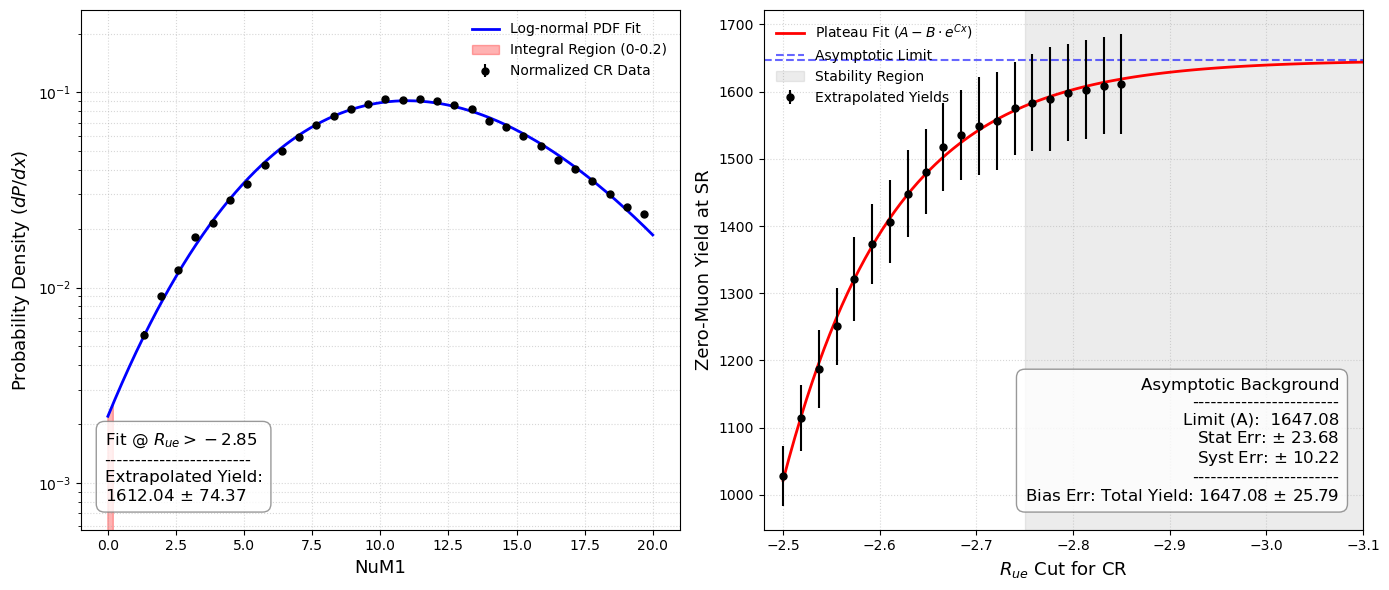

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm
from scipy.optimize import curve_fit
import scipy.integrate as integrate

# ====================================================================
# 核心函数定义
# ====================================================================

def lognorm_pdf(x, amplitude, s, loc, scale):
    """带幅值的对数正态分布 PDF"""
    return amplitude * lognorm.pdf(x, s=s, loc=loc, scale=scale)

def plateau_func(x, A, B, C):
    """背景极限外推公式"""
    return A - B * np.exp(C * x)

def extrapolate_zero_muon_yield(df, sr_threshold=-2.85, fit_range=(1, 20), integral_range=(0, 0.2), bins=30):
    """单个 R_ue 切迹下的 NuM1 拟合与积分外推"""
    cr_mask = (df['R_ue'] > sr_threshold) & (df['NuM1'] >= fit_range[0]) & (df['NuM1'] <= fit_range[1])
    df_cr = df[cr_mask]
    total_weight = df_cr['weight_norm'].sum()
    
    if total_weight == 0:
        return 0.0, 0.0, None

    # 计算 Density Histogram
    counts, bin_edges = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, 
                                     weights=df_cr['weight_norm'], density=True)
    counts = counts.astype(float)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_width = bin_edges[1] - bin_edges[0]
    
    # 计算密度误差 (Error = sqrt(sum(w^2)) / (Total_Weight * bin_width))
    counts_sq, _ = np.histogram(df_cr['NuM1'], bins=bins, range=fit_range, weights=df_cr['weight_norm']**2)
    y_err = np.sqrt(counts_sq.astype(float)) / (total_weight * bin_width)
    
    valid_mask = (counts > 0)
    x_fit = bin_centers[valid_mask]
    y_fit = counts[valid_mask]
    y_err_fit = y_err[valid_mask]

    # 初始猜测与拟合
    peak_idx = np.argmax(y_fit)
    p0 = [1.0, 0.7, 0, x_fit[peak_idx]]
    
    try:
        popt, pcov = curve_fit(lognorm_pdf, x_fit, y_fit, p0=p0, sigma=y_err_fit, 
                               absolute_sigma=True, maxfev=20000)
    except RuntimeError:
        return 0.0, 0.0, None
    
    # 积分与权重缩放
    prob_extrap, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(popt))
    yield_extrap = prob_extrap * total_weight
    
    # 蒙特卡洛误差采样
    samples = np.random.multivariate_normal(popt, pcov, 1000)
    integrals = []
    for samp in samples:
        try:
            if samp[1] <= 0 or samp[3] <= 0: continue 
            val, _ = integrate.quad(lognorm_pdf, integral_range[0], integral_range[1], args=tuple(samp))
            integrals.append(val * total_weight)
        except:
            continue
            
    yield_extrap_err = np.std(integrals) if len(integrals) > 0 else 0.0

    # 打包用于绘图的数据
    plot_data = {
        'x_fit': x_fit, 'y_fit': y_fit, 'y_err': y_err_fit, 'popt': popt,
        'fit_range': fit_range, 'integral_range': integral_range, 'total_weight': total_weight
    }
    
    return yield_extrap, yield_extrap_err, plot_data

# ====================================================================
# 1. 扫描计算 (Scan Compute)
# ====================================================================

Rue_cut_values = np.linspace(-2.5, -2.85, 20)
extrap_yield_list = []
extrap_err_list = []

# 用于保存最具代表性的一组拟合数据（通常选取贴近 SR 的点，比如最严格切迹）
representative_cut = -2.85 
rep_plot_data = None
rep_yield = 0.0
rep_err = 0.0
exp_temp_df_CRrecE_lowE = exp_temp_df[(exp_temp_df['recE'] > 1.90) & (exp_temp_df['recE'] < 1.95)]
# exp_temp_df_CRrecE_lowE= exp_muon_Rue_df_large[(exp_muon_Rue_df_large['recE'] > 1.90) & (exp_muon_Rue_df_large['recE'] < 1.95   )]
vali_num=exp_temp_df_CRrecE_lowE[exp_temp_df_CRrecE_lowE['R_ue']<-5]['weight_norm'].sum()
print(f"{vali_num} / {exp_temp_df_CRrecE_lowE['weight_norm'].sum()}")
print(">>> 开始扫描 R_ue 切迹并外推 Zero-Muon 产额...")
for cut in Rue_cut_values:
    y_extrap, y_err, p_data = extrapolate_zero_muon_yield(exp_temp_df_CRrecE_lowE, sr_threshold=cut)
    extrap_yield_list.append(y_extrap)
    extrap_err_list.append(y_err)
    
    # 保存 -2.85 (最紧切迹) 的拟合状态用于展示
    if np.isclose(cut, representative_cut) and p_data is not None:
        rep_plot_data = p_data
        rep_yield = y_extrap
        rep_err = y_err

# ====================================================================
# 2. 极限平台拟合 (Plateau Fit)
# ====================================================================

y_max, y_min = np.max(extrap_yield_list), np.min(extrap_yield_list)
p0_A = y_max * 1.1 
p0_C = 5.0 
p0_B = (p0_A - y_min) / np.exp(p0_C * Rue_cut_values[0])

try:
    popt_plat, pcov_plat = curve_fit(
        plateau_func, Rue_cut_values, extrap_yield_list, 
        p0=[p0_A, p0_B, p0_C], sigma=extrap_err_list, absolute_sigma=True,
        bounds=([y_max, 0, 0], [y_max*5, np.inf, 20]), maxfev=100000
    )
    perr_plat = np.sqrt(np.diag(pcov_plat))
except Exception as e:
    print(f"[WARNING] 拟合平台失败: {e}")
    popt_plat, perr_plat = [p0_A, p0_B, p0_C], [0, 0, 0]

A_val, A_err = popt_plat[0], perr_plat[0]

# 系统误差：靠近平台区 (R_ue < -2.75) 点的离散度
plateau_mask = Rue_cut_values < -2.75
stability_syst = np.std(np.array(extrap_yield_list)[plateau_mask])

print(f"\n>>> 最终 Zero-Muon 产额评估 (A): {A_val:.2f} ± {A_err:.2f} (Stat) ± {stability_syst:.2f} (Syst)")
print(f"bias factor: {np.abs(A_val-vali_num)/A_val:.2%}")
# ====================================================================
# 3. 联合绘图 (1x2 Subplots)
# ====================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ----------------- 子图 1: Representative NuM1 Fit -----------------
ax1 = axes[0]
if rep_plot_data is not None:
    x_f, y_f, y_e, popt = rep_plot_data['x_fit'], rep_plot_data['y_fit'], rep_plot_data['y_err'], rep_plot_data['popt']
    x_range, i_range = rep_plot_data['fit_range'], rep_plot_data['integral_range']
    
    ax1.errorbar(x_f, y_f, yerr=y_e, fmt='ko', markersize=5, label='Normalized CR Data', zorder=5)
    
    # 拟合曲线
    x_plot1 = np.linspace(1e-3, x_range[1], 1000) # 避开0点防止log报错
    y_plot1 = lognorm_pdf(x_plot1, *popt)
    ax1.plot(x_plot1, y_plot1, 'b-', linewidth=2, label='Log-normal PDF Fit')
    
    # 积分区域填充
    x_fill = np.linspace(i_range[0]+1e-5, i_range[1], 100)
    y_fill = lognorm_pdf(x_fill, *popt)
    ax1.fill_between(x_fill, 1e-10, y_fill, color='red', alpha=0.3, label=f'Integral Region ({i_range[0]}-{i_range[1]})')

    ax1.set_yscale('log')
    ax1.set_ylim(bottom=max(1e-6, np.min(y_f)*0.1)) # 动态下界保护
    ax1.set_xlabel("NuM1", fontsize=13)
    ax1.set_ylabel("Probability Density ($dP/dx$)", fontsize=13)
    ax1.grid(True, which="both", ls=":", alpha=0.5)
    ax1.legend(loc='upper right', frameon=False)
    
    # Text Box
    text1 = (f"Fit @ $R_{{ue}} > {representative_cut}$\n"
             f"------------------------\n"
             f"Extrapolated Yield:\n"
             f"{rep_yield:.2f} $\pm$ {rep_err:.2f}")
    ax1.text(0.04, 0.05, text1, transform=ax1.transAxes, fontsize=12,
             verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# ----------------- 子图 2: Plateau Extrapolation -----------------
ax2 = axes[1]
ax2.errorbar(Rue_cut_values, extrap_yield_list, yerr=extrap_err_list, 
             fmt='ko', markersize=5, label='Extrapolated Yields', zorder=5)

x_plot2 = np.linspace(Rue_cut_values[0], -3.1, 100)
y_plot2 = plateau_func(x_plot2, *popt_plat)

ax2.plot(x_plot2, y_plot2, 'r-', lw=2, label='Plateau Fit ($A - B \cdot e^{Cx}$)')
ax2.axhline(A_val, color='blue', linestyle='--', alpha=0.6, label='Asymptotic Limit')

# 标识出计算系统误差的平台稳定区
ax2.axvspan(-3.1, -2.75, color='gray', alpha=0.15, label='Stability Region')

ax2.set_xlabel(r"$R_{ue}$ Cut for CR", fontsize=13)
ax2.set_ylabel("Zero-Muon Yield at SR", fontsize=13)
ax2.grid(True, ls=":", alpha=0.5)
ax2.set_xlim(Rue_cut_values[0]+0.02, -3.1) # X轴反向显示更符合逼近 SR 的直觉
ax2.legend(loc='upper left', frameon=False)

# Text Box
text2 = (f"Asymptotic Background\n"
         f"------------------------\n"
         f"Limit (A):  {A_val:.2f}\n"
         f"Stat Err: $\pm$ {A_err:.2f}\n"
         f"Syst Err: $\pm$ {stability_syst:.2f}\n"
         f"------------------------\n"
         f"Bias Err: "
         f"Total Yield: {A_val:.2f} $\pm$ {np.sqrt(A_err**2 + stability_syst**2):.2f}")
ax2.text(0.96, 0.05, text2, transform=ax2.transAxes, fontsize=12,
         verticalalignment='bottom', horizontalalignment='right', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

In [54]:

def apply_analysis_cuts(df, Rue_cut, re_weight=False, weights_col='weight', dataset_name="Dataset", sig_exp=False):
    cond_E = (df['recE'] > SR_recE_low) & (df['recE'] < SR_recE_high)
    cond_Rue = (df['R_ue'] < Rue_cut) & (df['R_ue'] > SR_limit) if not sig_exp else (df['R_ue'] < SR_limit)
    mask = cond_E & cond_Rue
    df_cut = df[mask].copy()
    if re_weight:
        df_cut[weights_col] = df_cut[weights_col] / df_cut[weights_col].sum() * bkg_yields
        
    print(f"{dataset_name}: after cuts, yield = {df_cut[weights_col].sum():.2f} (N={len(df_cut)})")
    return df_cut

sideband_thresholds=[-2.55, -2.6, -2.65, -2.7, -2.75, ]
SR_limit=-2.85
SR_recE_low = 1.95
SR_recE_high = 2.1
reference_thresh=-2.7
TIME_SCALE = 1473 / 365
bkg_yields = (N_lessMuon + N_zeroMuon) * TIME_SCALE
bkg_nominal = apply_analysis_cuts(exp_muon_Rue_df_large, reference_thresh, re_weight=True, weights_col='weight', dataset_name="Bkg_Nominal")

bkg_variations = []
for thresh in sideband_thresholds:
    if thresh == reference_thresh:
        continue
    bkg_var = apply_analysis_cuts(exp_muon_Rue_df_large, thresh, re_weight=True, weights_col='weight', dataset_name=f"Bkg_Var_Rue_{thresh:.2f}")
    bkg_var['weight'] = bkg_var['weight'] * (bkg_yields / bkg_var['weight'].sum())
    bkg_variations.append(bkg_var)

sig_nominal = apply_analysis_cuts(mn_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Sig_Nominal", sig_exp=True)
exp_data = apply_analysis_cuts(exp_muon_Rue_df_large, SR_limit, re_weight=False, weights_col='weight', dataset_name="Exp_Data", sig_exp=True)



# 估计信号MC与真实的差异
# 通过全组分,另一个模型背景与数据的差异应用到sig上
recE_shift = 3e-4  
R_ue_shift = 3.5e-3
def apply_shift_cut_sig(df, recE_shift, Rue_shift):
    mask = (df['recE'] > SR_recE_low + recE_shift) & (df['recE'] < SR_recE_high + recE_shift) & \
           (df['R_ue'] < SR_limit + Rue_shift)
    return df[mask].copy()
sig_recE_shifted_up = apply_shift_cut_sig(sig_nominal, recE_shift, 0)
sig_recE_shifted_down = apply_shift_cut_sig(sig_nominal, -recE_shift, 0)
sig_Rue_shifted_up = apply_shift_cut_sig(sig_nominal, 0, R_ue_shift)
sig_Rue_shifted_down = apply_shift_cut_sig(sig_nominal, 0, -R_ue_shift)

sig_variations = {
    'recE_up': sig_recE_shifted_up,
    'recE_down': sig_recE_shifted_down,
    'R_ue_up': sig_Rue_shifted_up,
    'R_ue_down': sig_Rue_shifted_down
}

# 计算每个变体的预期信号事件数
def calculate_expected_signal(df):
    return df['weight'].sum()
sig_nominal_yield = calculate_expected_signal(sig_nominal)
sig_recE_up_yield = calculate_expected_signal(sig_recE_shifted_up)
sig_recE_down_yield = calculate_expected_signal(sig_recE_shifted_down)
sig_Rue_up_yield = calculate_expected_signal(sig_Rue_shifted_up)
sig_Rue_down_yield = calculate_expected_signal(sig_Rue_shifted_down)


print(f"Signal Nominal Yield: {sig_nominal_yield:.4e}")
print(f"Signal RecE Shifted Up Yield: {sig_recE_up_yield:.4e}, Percent Change: {(sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal RecE Shifted Down Yield: {sig_recE_down_yield:.4e}, Percent Change: {(sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Up Yield: {sig_Rue_up_yield:.4e}, Percent Change: {(sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")
print(f"Signal R_ue Shifted Down Yield: {sig_Rue_down_yield:.4e}, Percent Change: {(sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield:.4%}")

sig_recE_sys_percent = max(abs((sig_recE_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_recE_down_yield - sig_nominal_yield) / sig_nominal_yield))
sig_Rue_sys_percent = max(abs((sig_Rue_up_yield - sig_nominal_yield) / sig_nominal_yield), abs((sig_Rue_down_yield - sig_nominal_yield) / sig_nominal_yield))
print(f"Estimated Signal Systematic Uncertainty from RecE Shift: {sig_recE_sys_percent:.4%}")
print(f"Estimated Signal Systematic Uncertainty from R_ue Shift: {sig_Rue_sys_percent:.4%}")

Bkg_Nominal: after cuts, yield = 28369.01 (N=28117)
Bkg_Var_Rue_-2.55: after cuts, yield = 28369.01 (N=82640)
Bkg_Var_Rue_-2.60: after cuts, yield = 28369.01 (N=60557)
Bkg_Var_Rue_-2.65: after cuts, yield = 28369.01 (N=42654)
Bkg_Var_Rue_-2.75: after cuts, yield = 28369.01 (N=16166)
Sig_Nominal: after cuts, yield = 0.00 (N=35992)
Exp_Data: after cuts, yield = 47094.00 (N=47094)
Signal Nominal Yield: 1.0613e-05
Signal RecE Shifted Up Yield: 1.0605e-05, Percent Change: -0.0765%
Signal RecE Shifted Down Yield: 1.0598e-05, Percent Change: -0.1374%
Signal R_ue Shifted Up Yield: 1.0613e-05, Percent Change: 0.0000%
Signal R_ue Shifted Down Yield: 1.0553e-05, Percent Change: -0.5676%
Estimated Signal Systematic Uncertainty from RecE Shift: 0.1374%
Estimated Signal Systematic Uncertainty from R_ue Shift: 0.5676%


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import copy
# ==========================================
# 0. 全局配置
# ==========================================

# 这里的特征必须与 DataFrame 中的列名完全一致
FEATURES = ['rec_theta', 'Eage', 'rho40', 'pincness', 'compactness','R_mean'] 
TARGET_FLUX = 'weight'

# ==========================================
# 1. 类定义 (保持你的架构，稍作优化)
# ==========================================
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        # drop_prob 通常在 0.2 到 0.5 之间
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(p=0.5),  # <--- 新增：丢弃50%的神经元连接

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(p=0.5),  # <--- 新增

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

from sklearn.metrics import roc_curve, auc

class ClassifierManager:
    def __init__(self, features, model_type='xgb', device='cpu'):
        self.features = features
        self.model_type = model_type.lower()
        self.device = device
        
        self.trained_models = []
        self.trained_scalers = []
        
        # [新增] 用于存储绘图数据
        self.loss_histories = [] # 存储每个Fold的 {'train': [], 'val': []}
        self.fold_roc_data = []  # 存储每个Fold的 (y_val, preds)
        
    def prepare_data(self, bkg_df, sig_df, weight_col='weight', sig_weight_col='weight'):
        X_bkg = bkg_df[self.features].values
        X_sig = sig_df[self.features].values
        
        w_bkg = bkg_df[weight_col].values
        w_sig = sig_df[sig_weight_col].values
        w_bkg = w_bkg / w_bkg.mean()
        w_sig = w_sig / w_sig.mean()

        self.X_raw = np.vstack([X_bkg, X_sig])
        self.y_raw = np.concatenate([np.zeros(len(X_bkg)), np.ones(len(X_sig))])
        self.w_raw = np.concatenate([w_bkg, w_sig])
        
        self.n_bkg = len(X_bkg)

    def _get_new_model(self):
        if self.model_type == 'xgb':
            return xgb.XGBClassifier(
                n_estimators=800, max_depth=4, learning_rate=0.03,
                objective='binary:logistic', n_jobs=-1, random_state=42,
                tree_method='gpu_hist' if 'cuda' in self.device else 'hist',
                early_stopping_rounds=50
            )
        elif self.model_type == 'mlp':
            return MLP(len(self.features)).to(self.device)

    def train_kfold(self, n_splits=5, epochs=2000):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        oof_preds = np.zeros(len(self.y_raw))
        
        self.trained_models = []
        self.trained_scalers = []
        self.loss_histories = [] # 重置历史
        self.fold_roc_data = []  # 重置ROC数据

        print(f">>> Starting {n_splits}-Fold Cross-Validation ({self.model_type})...")

        for fold, (train_idx, val_idx) in enumerate(skf.split(self.X_raw, self.y_raw)):
            print(f"\n--- Fold {fold+1}/{n_splits} ---")
            
            X_train, y_train, w_train = self.X_raw[train_idx], self.y_raw[train_idx], self.w_raw[train_idx]
            X_val, y_val, w_val = self.X_raw[val_idx], self.y_raw[val_idx], self.w_raw[val_idx]
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            self.trained_scalers.append(scaler)
            
            model = self._get_new_model()
            
            # [新增] 当前Fold的Loss记录
            fold_history = {'train': [], 'val': []}

            if self.model_type == 'xgb':
                model.fit(X_train_scaled, y_train, sample_weight=w_train, eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
                    sample_weight_eval_set=[w_train, w_val],
                    verbose=50 # 关闭详细打印，保持整洁
                )
                # XGBoost 获取 loss history 比较特殊，这里简化处理，只处理 MLP 的需求
                # 如果需要 XGB 的 Loss 图，需要从 model.evals_result() 获取
                try:
                    limit = model.best_iteration + 1
                    preds = model.predict_proba(X_val_scaled, iteration_range=(0, limit))[:, 1]
                except AttributeError:
                    preds = model.predict_proba(X_val_scaled)[:, 1]

            elif self.model_type == 'mlp':
                Xt = torch.FloatTensor(X_train_scaled).to(self.device)
                yt = torch.FloatTensor(y_train).unsqueeze(1).to(self.device)
                wt = torch.FloatTensor(w_train).unsqueeze(1).to(self.device)
                
                Xv = torch.FloatTensor(X_val_scaled).to(self.device)
                yv = torch.FloatTensor(y_val).unsqueeze(1).to(self.device)
                wv = torch.FloatTensor(w_val).unsqueeze(1).to(self.device)
                
                optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
                criterion = nn.BCELoss(reduction='none')
                
                for epoch in range(epochs):
                    model.train()
                    optimizer.zero_grad()
                    out = model(Xt)
                    loss_train = (criterion(out, yt) * wt).mean()
                    loss_train.backward()
                    optimizer.step()
                    
                    # [新增] 每个Epoch都记录验证集 Loss (为了画平滑的曲线)
                    model.eval()
                    with torch.no_grad():
                        out_val = model(Xv)
                        loss_val = (criterion(out_val, yv) * wv).mean()
                    
                    # 记录历史
                    fold_history['train'].append(loss_train.item())
                    fold_history['val'].append(loss_val.item())

                    if (epoch + 1) % 100 == 0:
                        print(f"Epoch [{epoch+1}/{epochs}] | Train: {loss_train.item():.5f} | Val: {loss_val.item():.5f}")

                model.eval()
                with torch.no_grad():
                    preds = model(Xv).cpu().numpy().flatten()
                
                # 记录本折的 Loss 历史
                self.loss_histories.append(fold_history)

            oof_preds[val_idx] = preds
            self.trained_models.append(model)
            # [新增] 记录本折的 ROC 数据
            self.fold_roc_data.append((y_val, preds))
            
        print("\n>>> K-Fold Training Complete.")
        return oof_preds

    def predict_ensemble(self, df):
        df_clean = df[self.features].copy()
        for col in self.features:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        df_clean = df_clean.fillna(0).infer_objects()
        X_raw = df_clean.values
        
        all_fold_preds = []
        for i, (model, scaler) in enumerate(zip(self.trained_models, self.trained_scalers)):
            X_scaled = scaler.transform(X_raw)
            if self.model_type == 'xgb':
                try:
                    if hasattr(model, 'best_iteration') and model.best_iteration is not None:
                        limit = model.best_iteration + 1
                        p = model.predict_proba(X_scaled, iteration_range=(0, limit))[:, 1]
                    else:
                        p = model.predict_proba(X_scaled)[:, 1]
                except:
                    p = model.predict_proba(X_scaled)[:, 1]
            elif self.model_type == 'mlp':
                model.eval()
                Xt = torch.FloatTensor(X_scaled).to(self.device)
                with torch.no_grad():
                    p = model(Xt).cpu().numpy().flatten()
            all_fold_preds.append(p)
        return np.mean(all_fold_preds, axis=0)
    
    def get_feature_importance(self):
        if self.model_type == 'xgb' and self.trained_models:
            return dict(zip(self.features, self.trained_models[0].feature_importances_))
        return {}

class Plotter:
    COLORS = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'cyan']
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="Score Distribution"):
        # 1. 设置画板：上大下小 (3:1)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                       gridspec_kw={'height_ratios': [3, 1]}, 
                                       sharex=True)
        
        hists = []
        edges = None
        
        # ==========================================
        # 上图：分布直方图 (Main Distribution)
        # ==========================================
        for i, (df, label, w) in enumerate(zip(dfs, labels, weights)):
            # 视觉样式：最后两个(Signal/Exp)用填充，其他的用线条
            is_ref = (i >= len(dfs) - 2) 
            h_type = 'stepfilled' if is_ref else 'step'
            alpha = 0.3 if is_ref else 1.0
            lw = 2 if not is_ref else 1.5
            color = Plotter.COLORS[i % len(Plotter.COLORS)]
            
            # 绘制并保存直方图数据
            # density=True 用于对比形状
            h, bin_edges, _ = ax1.hist(df['mlp_score'], bins=bins, range=(0, 1), weights=w,
                                       histtype=h_type, alpha=alpha, lw=lw, density=True, 
                                       label=label, color=color)
            hists.append(h)
            if edges is None: edges = bin_edges
            
        ax1.set_ylabel('Normalized Density')
        # ax1.set_yscale('log') # 强烈建议 Score 开启 Log 模式，否则看不到高分段细节
        ax1.set_title(title)
        # 图例放上面，避免遮挡数据
        ax1.legend(loc='upper center',  ncol=3, frameon=False)
        ax1.grid(True, which='both', linestyle='--', alpha=0.3)

        # ==========================================
        # 下图：比例图 (Ratio Plot)
        # ==========================================
        # 默认以第一个数据集 (dfs[0], 即 Baseline) 作为分母
        ref_h = hists[0]
        centers = 0.5 * (edges[:-1] + edges[1:])
        
        for i in range(1, len(hists)):
            # 计算 Ratio，处理除零情况
            # 信号 (Signal) 分布通常和背景差异极大，画 Ratio 可能会让图变得很乱
            # 你可以选择跳过 Signal (通常 label 包含 'Signal' 或 'MN')
            if 'Signal' in labels[i] or 'MN' in labels[i]:
                continue

            ratio = np.divide(hists[i], ref_h, out=np.zeros_like(ref_h), where=ref_h!=0)
            
            # 只画有数据的点，避免由 0/0 产生的噪点
            mask = ref_h > 0
            ax2.plot(centers[mask], ratio[mask], 'o-', markersize=3, lw=1,
                     color=Plotter.COLORS[i % len(Plotter.COLORS)])
        
        # 参考线
        ax2.axhline(1, color='gray', linestyle='--')
        
        ax2.set_xlabel('Classification Score (0=Bkg, 1=Sig)')
        ax2.set_ylabel('Ratio / Baseline')
        
        # 设置 Ratio 的显示范围，避免个别极端值破坏视图
        ax2.set_ylim(0.0, 2.0) 
        ax2.grid(True, which='both', linestyle='--', alpha=0.3)
        
        # 调整间距
        plt.subplots_adjust(hspace=0.05)
        plt.show()


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ==========================================
# 2. 数据准备与 Cut 策略
# ==========================================
print("\n>>> Step A: Applying Physics Cuts...")

# 1. 训练用背景 (使用 Shape Invariant Template: Rue < -1.5)
# 注意：pr_df_large_cut 已经是 Rue < -1.5 了，这里再加 recE cut
print(f"Original Bkg: yield = {bkg_nominal[TARGET_FLUX].sum():.2f} (N={len(bkg_nominal)})")
bkg_nominal_train = bkg_nominal.copy()
# bkg_nominal_train = bkg_nominal_train.sample(10000, random_state=42, replace=False).copy()
# bkg_nominal_train[TARGET_FLUX] *= pr_df_large_cut[TARGET_FLUX].sum() / bkg_nominal_train[TARGET_FLUX].sum()
# bkg_nominal_train = apply_analysis_cuts(bkg_nominal_train, "Bkg Train Final")

# 2. 训练用信号
print(f"Original Signal: yield = {sig_nominal[TARGET_FLUX].sum():.2f} (N={len(sig_nominal)})")
# sig_nominal_train = sig_nominal.sample(20000, random_state=42, replace=False).copy()
# sig_nominal_train['weight'] *= sig_nominal['weight'].sum() / sig_nominal_train['weight'].sum()
sig_nominal_train = sig_nominal
# 3. 实验数据
exp_data = exp_data.copy()

# ==========================================
# 3. K-Fold 训练
# ==========================================
print("\n>>> Step B: K-Fold Training & OOF Prediction...")

# manager = ClassifierManager(FEATURES, model_type='xgb', device='cpu')
manager = ClassifierManager(FEATURES, model_type='mlp', device='cpu')
manager.prepare_data(bkg_nominal_train, sig_nominal_train, weight_col=TARGET_FLUX, sig_weight_col='weight')
oof_scores_total = manager.train_kfold(n_splits=5, epochs=3000)

# 将 OOF 分数拆分回 Bkg 和 Sig DataFrame
# 顺序必须和 prepare_data 中的合并顺序一致 (先 Bkg 后 Sig)
n_bkg = manager.n_bkg
bkg_nominal_train['mlp_score'] = oof_scores_total[:n_bkg]
sig_nominal_train['mlp_score'] = oof_scores_total[n_bkg:]

print("OOF Scores assigned back to training dataframes.")

# ==========================================
# 4. 外部数据集成预测 (Ensemble Prediction)
# ==========================================
print("\n>>> Step C: Ensemble Inference on External Data...")
exp_data['mlp_score'] = manager.predict_ensemble(exp_data)
bkg_var_final_list = []
for bkg_var in bkg_variations:
    bkg_var['mlp_score'] = manager.predict_ensemble(bkg_var)
    bkg_var_final_list.append(bkg_var)

sig_var_final_list = []
for sig_var_name, sig_var_df in sig_variations.items():
    sig_var_df['mlp_score'] = manager.predict_ensemble(sig_var_df)
    sig_var_final_list.append(sig_var_df)
# ==========================================
# 5. 结果可视化与检查
# ==========================================
print("\n>>> Step D: Visualizing Results...")

# 输出高分区的统计信息
CUT_SCORE = 0.
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")


# 输出高分区的统计信息
CUT_SCORE = 0.9
n_exp = exp_data[exp_data['mlp_score'] > CUT_SCORE]['weight'].sum()
n_bkg = bkg_nominal_train[bkg_nominal_train['mlp_score'] > CUT_SCORE][TARGET_FLUX].sum()
n_sig = sig_nominal_train[sig_nominal_train['mlp_score'] > CUT_SCORE]['weight'].sum()

print(f"\n[Check] Events with Score > {CUT_SCORE} (Annualized):")
print(f"  Exp Data: {n_exp:.2f}")
# print(f"  MC Bkg :  {n_bkg*365*86400:.2f}")
print(f"  Signal :  {n_sig*365*86400:.2f}")




>>> Step A: Applying Physics Cuts...
Original Bkg: yield = 28369.01 (N=28117)
Original Signal: yield = 0.00 (N=35992)

>>> Step B: K-Fold Training & OOF Prediction...
>>> Starting 5-Fold Cross-Validation (mlp)...

--- Fold 1/5 ---
Epoch [100/3000] | Train: 0.36045 | Val: 0.31956
Epoch [200/3000] | Train: 0.33334 | Val: 0.29727
Epoch [300/3000] | Train: 0.32231 | Val: 0.29148
Epoch [400/3000] | Train: 0.31441 | Val: 0.28911
Epoch [500/3000] | Train: 0.31143 | Val: 0.28762
Epoch [600/3000] | Train: 0.31023 | Val: 0.28641
Epoch [700/3000] | Train: 0.30731 | Val: 0.28551
Epoch [800/3000] | Train: 0.30457 | Val: 0.28449
Epoch [900/3000] | Train: 0.30163 | Val: 0.28383
Epoch [1000/3000] | Train: 0.30049 | Val: 0.28357
Epoch [1100/3000] | Train: 0.30034 | Val: 0.28296
Epoch [1200/3000] | Train: 0.29851 | Val: 0.28287
Epoch [1300/3000] | Train: 0.29721 | Val: 0.28232
Epoch [1400/3000] | Train: 0.29665 | Val: 0.28216
Epoch [1500/3000] | Train: 0.29625 | Val: 0.28177
Epoch [1600/3000] | Train: 

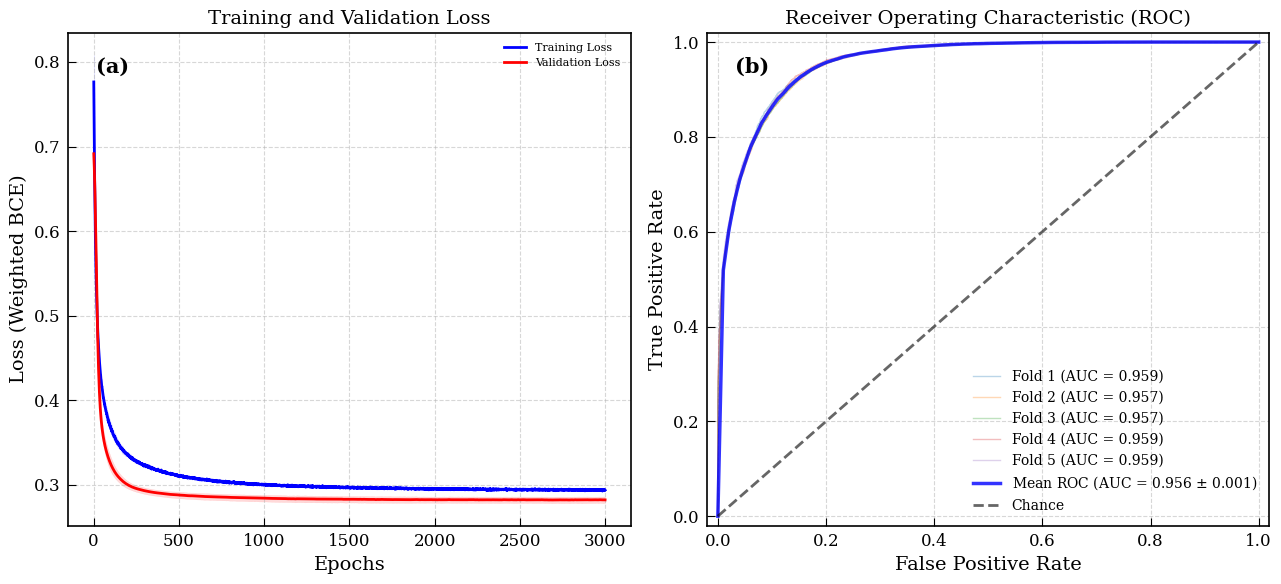

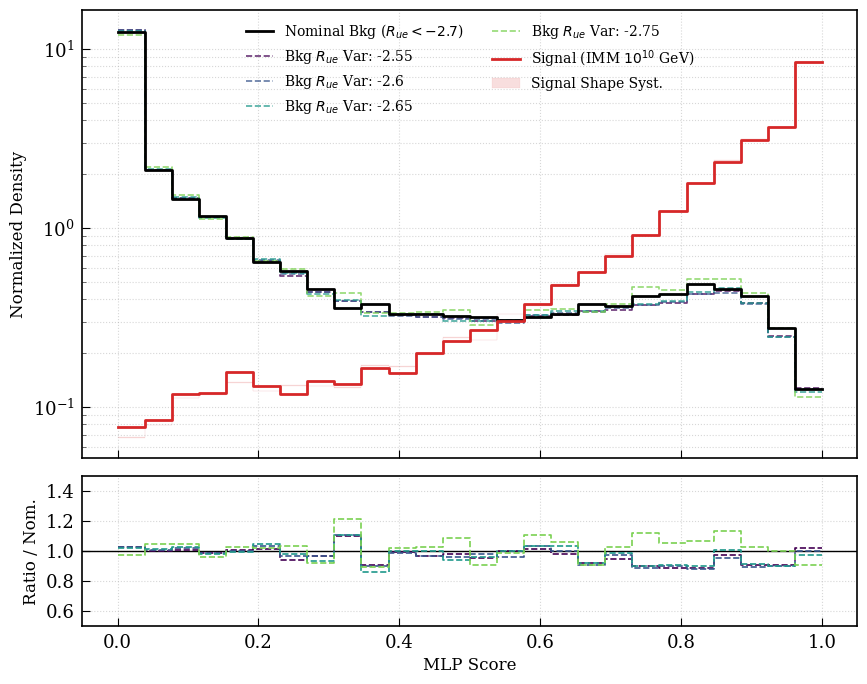

In [59]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格 (可选，如果没有安装 latex 可以注释掉 usetex=True)
def plot_training_evaluation(manager, output_dir="."):
    """
    绘制 Loss 曲线和 ROC 曲线
    """
    # 设置学术风格
    plt.style.use('seaborn-v0_8-paper')
    plt.rcParams.update({'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14, 'xtick.labelsize': 12, 'ytick.labelsize': 12})
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    
    # ==========================================
    # 1. Loss Curve (Mean +/- Std)
    # ==========================================
    ax1 = axes[0]
    if manager.model_type == 'mlp' and manager.loss_histories:
        # 获取所有 fold 的 loss
        train_losses = np.array([h['train'] for h in manager.loss_histories])
        val_losses = np.array([h['val'] for h in manager.loss_histories])
        
        # 计算均值和标准差
        mean_train = np.mean(train_losses, axis=0)
        std_train = np.std(train_losses, axis=0)
        mean_val = np.mean(val_losses, axis=0)
        std_val = np.std(val_losses, axis=0)
        epochs = range(1, len(mean_train) + 1)
        
        # 绘图
        ax1.plot(epochs, mean_train, 'b-', label='Training Loss', lw=2)
        ax1.fill_between(epochs, mean_train - std_train, mean_train + std_train, color='b', alpha=0.15)
        
        ax1.plot(epochs, mean_val, 'r-', label='Validation Loss', lw=2)
        ax1.fill_between(epochs, mean_val - std_val, mean_val + std_val, color='r', alpha=0.15)
        
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss (Weighted BCE)')
        ax1.text(0.05, 0.95, '(a)',  transform=ax1.transAxes, fontsize=15, fontweight='bold', va='top')
        ax1.set_title('Training and Validation Loss')
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.5)
    else:
        ax1.text(0.5, 0.5, 'Loss history available only for MLP', ha='center', transform=ax1.transAxes)

    # ==========================================
    # 2. ROC Curve (K-Fold Mean)
    # ==========================================
    ax2 = axes[1]
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # 绘制每一折的 ROC
    for i, (y_true, y_score) in enumerate(manager.fold_roc_data):
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值以便计算平均
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        # 绘制浅色细线
        ax2.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Fold {i+1} (AUC = {roc_auc:.3f})')
        
    # 绘制平均 ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    
    ax2.plot(mean_fpr, mean_tpr, color='b', label=rf'Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})', lw=2.5, alpha=0.8)
    
    # 绘制对角线
    ax2.plot([0, 1], [0, 1], linestyle='--', lw=2, color='k', label='Chance', alpha=0.6)
    
    ax2.set_xlim([-0.02, 1.02])
    ax2.set_ylim([-0.02, 1.02])
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title('Receiver Operating Characteristic (ROC)')
    ax2.text(0.05, 0.95, '(b)',  transform=ax2.transAxes, fontsize=15, fontweight='bold', va='top')
    ax2.legend(loc="lower right", fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    fig.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_model_evaluation_metrics.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    # 如果需要保存
   
plot_training_evaluation(manager)

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# 设置全局绘图风格：Times New Roman 字体，向内的刻度
plt.rcParams.update({
    'font.family': 'serif',
    "font.serif": [ "DejaVu Serif", "serif"],
    'font.size': 12,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False,  # 去掉图例边框
    'figure.figsize': (10, 8),
    'axes.linewidth': 1.2     # 边框加粗
})

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

class Plotter:
    # 更加稳重、对比度高的学术配色
    COLORS = {
        'bkg_nom': 'black',      # 基准背景
        'signal':  '#d62728',    # 信号
        'data':    'black'       # 数据点
    }
    
    @staticmethod
    def plot_score(dfs, labels, weights, bins=50, title="MLP Score Distribution"):
        fig = plt.figure(figsize=(10, 8))
        gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
        ax1 = fig.add_subplot(gs[0])
        ax2 = fig.add_subplot(gs[1], sharex=ax1)

        # 1. 预计算所有直方图 (Density=True 用于形态对比)
        hists = []
        edges = None
        for df, w in zip(dfs, weights):
            h, e = np.histogram(df['mlp_score'], bins=bins, range=(0, 1), weights=w, density=True)
            hists.append(h)
            if edges is None:
                edges = e

        # 2. 自动对输入数据进行分类 (通过 Label 识别 Signal 和 Background)
        idx_bkg_nom = 0
        idx_bkg_vars = []
        idx_sig_nom = -1
        idx_sig_vars = []

        for i, lbl in enumerate(labels):
            if i == 0:
                pass # 第0个默认是基准背景
            elif 'Signal' in lbl or 'sig' in lbl.lower():
                if idx_sig_nom == -1:
                    idx_sig_nom = i     # 碰到的第一个 Signal 设为 Nominal Signal
                else:
                    idx_sig_vars.append(i) # 后续的 Signal 设为 Variations
            else:
                idx_bkg_vars.append(i)  # 剩下的全是 Background Variations

        # 生成背景变分的渐变色
        n_bkg_sys = len(idx_bkg_vars)
        sys_colors = plt.cm.viridis(np.linspace(0, 0.8, n_bkg_sys)) if n_bkg_sys > 0 else []

        # =========================================================
        # 主图 (ax1) 绘制逻辑
        # =========================================================
        
        # A. 画基准背景
        h_bkg_nom = hists[idx_bkg_nom]
        ax1.step(edges, np.append(h_bkg_nom, h_bkg_nom[-1]), where='post', 
                 color=Plotter.COLORS['bkg_nom'], lw=2, zorder=10, label=labels[idx_bkg_nom])
        
        # B. 画背景变分 (虚线)
        for c_idx, i in enumerate(idx_bkg_vars):
            h_var = hists[i]
            ax1.step(edges, np.append(h_var, h_var[-1]), where='post', 
                     color=sys_colors[c_idx], lw=1.2, alpha=0.8, ls='--', label=labels[i])

        # C. 画信号 (基准为实线，变分为阴影包络带)
        if idx_sig_nom != -1:
            h_sig_nom = hists[idx_sig_nom]
            ax1.step(edges, np.append(h_sig_nom, h_sig_nom[-1]), where='post', 
                     color=Plotter.COLORS['signal'], lw=2, zorder=11, label=labels[idx_sig_nom])
            
            # 如果存在信号变分，计算 Min/Max 形成包络线
            if len(idx_sig_vars) > 0:
                sig_var_arrays = np.array([hists[i] for i in idx_sig_vars])
                sig_max = np.max(sig_var_arrays, axis=0)
                sig_min = np.min(sig_var_arrays, axis=0)
                
                # 使用 fill_between 绘制信号的系统误差阴影带 (仅添加一个图例)
                ax1.fill_between(edges, 
                                 np.append(sig_min, sig_min[-1]), 
                                 np.append(sig_max, sig_max[-1]), 
                                 step='post', color=Plotter.COLORS['signal'], 
                                 alpha=0.15, zorder=1, label='Signal Shape Syst.')

        # 主图修饰
        ax1.set_yscale('log')
        ax1.set_ylabel('Normalized Density', fontsize=12)
        ax1.legend(loc='best', ncol=2, fontsize=10, frameon=False)
        ax1.grid(True, which='both', ls=':', alpha=0.5)
        # ax1.set_ylim(1e-3, 15) # 建议手动给一个合理的下限，防止 log 轴底部太杂乱

        # =========================================================
        # Ratio Plot (ax2) 绘制逻辑 - 仅比较背景
        # =========================================================
        ax2.axhline(1, color='black', lw=1, ls='-')
        
        for c_idx, i in enumerate(idx_bkg_vars):
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = hists[i] / h_bkg_nom
                # 把除以 0 产生的 nan 或 inf 设为 1，防止画图崩溃
                ratio = np.nan_to_num(ratio, nan=1.0, posinf=1.0, neginf=1.0)
            
            ax2.step(edges, np.append(ratio, ratio[-1]), where='post', 
                     color=sys_colors[c_idx], lw=1.2, ls='--')

        # Ratio 轴修饰
        ax2.set_ylabel('Ratio / Nom.', fontsize=12)
        ax2.set_xlabel('MLP Score', fontsize=12)
        ax2.set_ylim(0.5, 1.5) 
        ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
        ax2.grid(True, ls=':', alpha=0.5)

        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_score_distribution.pdf", dpi=300, bbox_inches='tight')
        plt.show()
# ==========================================
# 调用部分
# ==========================================
rue_cuts = np.array(sideband_thresholds)
rue_cuts = rue_cuts[rue_cuts != reference_thresh] # 去掉 Nominal 的 cut

dfs_to_plot = [bkg_nominal_train, *bkg_var_final_list, sig_nominal_train, *sig_var_final_list]

# 优化标签：带 "Signal" 关键字的会被自动归为信号组
labels = [
    r'Nominal Bkg ($R_{{ue}} < -2.7$)', 
    *[r'Bkg $R_{{ue}}$ Var: {}'.format(c) for c in rue_cuts[:len(bkg_var_final_list)]],
    r'Signal (IMM $10^{10}$ GeV)',      # <-- 被识别为 Nominal Signal
    r'Signal RecE Shift Up',            # <-- 以下4个被识别为 Signal Vars，用于画阴影
    r'Signal RecE Shift Down',
    r'Signal R_ue Shift Up',
    r'Signal R_ue Shift Down'
]

# 权重逻辑保持不变
weights_to_plot = []
for df in dfs_to_plot:
    if 'mlp_score' in df.columns:
        w_col = 'weight' if 'trueE' in df.columns else TARGET_FLUX
        weights_to_plot.append(df[w_col])

# 调用绘图函数
Plotter.plot_score(dfs_to_plot, labels, weights_to_plot, bins=26, title="LHAASO-KM2A Monopole Search")

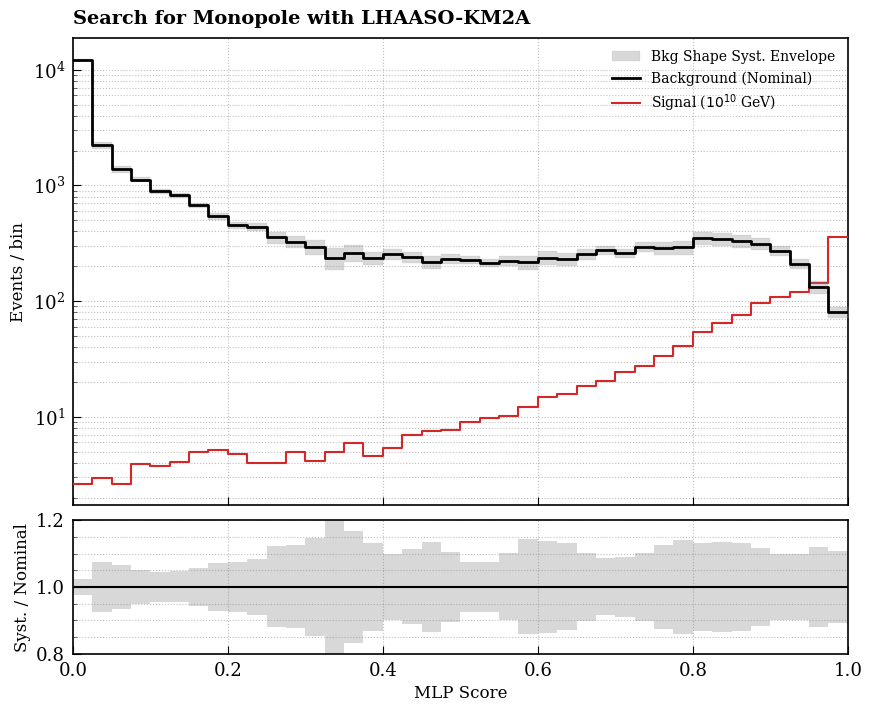

1349.7379989636856
28369.00941708075
47094
>>> ROOT file for RooStats generated successfully.
>>> HistFactory XML configuration file generated successfully.


In [65]:
def get_hist_counts(df, score_col='mlp_score', weight_col='weight', bins=25):
    counts, _ = np.histogram(df[score_col], bins=bins, range=(0, 1), weights=df[weight_col])
    variances, _ = np.histogram(df[score_col], bins=bins, weights=df[weight_col]**2)
    return counts, variances

from scipy.ndimage import gaussian_filter1d

def smooth_systematic_envelope(nominal, max_diff, sigma=1.0):
    """
    对系统误差的最大偏差进行平滑处理
    sigma: 平滑强度。通常设置在 1.0 - 1.5 之间。
           sigma 越大，曲线越平滑，但过大可能会抹去真实的物理趋势。
    """
    # 1. 对偏差进行平滑处理
    # 使用 mode='nearest' 处理边界，防止两端塌陷
    max_diff_smoothed = gaussian_filter1d(max_diff, sigma=sigma, mode='nearest')
    
    # 2. 重新生成对称包络线
    bkg_var_max_smoothed = nominal + max_diff_smoothed
    bkg_var_min_smoothed = nominal - max_diff_smoothed
    
    # 确保最小不会变成负数
    bkg_var_min_smoothed = np.maximum(bkg_var_min_smoothed, 0)
    
    return bkg_var_max_smoothed, bkg_var_min_smoothed


BINS_FIT = 40
BINS_PLOT = BINS_FIT
exp_final_hist, exp_final_var = get_hist_counts(exp_data, bins=BINS_FIT)
bkg_nominal_final_hist, bkg_nominal_final_var = get_hist_counts(bkg_nominal_train, bins=BINS_FIT)
bkg_var_final_hists = [get_hist_counts(bkg_var, bins=BINS_FIT)[0] for bkg_var in bkg_var_final_list]
bkg_var_final_vars = [get_hist_counts(bkg_var, bins=BINS_FIT)[1] for bkg_var in bkg_var_final_list]
sig_final_hist, sig_final_var = get_hist_counts(sig_nominal_train, bins=BINS_FIT)


TIMESCALE_FACTOR = 1472 * 86400  # 将事件数转换为年事件数
sig_final_hist = sig_final_hist * TIMESCALE_FACTOR
bkg_nominal_fit = bkg_nominal_final_hist  # 使用原始的 nominal 作为拟合基础

# 找到每个 bin 在所有变分中的真实最大值和最小值
bkg_all_array = np.array([bkg_nominal_final_hist] + bkg_var_final_hists)
bkg_var_max_raw = np.max(bkg_all_array, axis=0)
bkg_var_min_raw = np.min(bkg_all_array, axis=0)
#==========================================================
# 然后分别对这两条线做平滑
# bkg_var_max = gaussian_filter1d(bkg_var_max_raw, sigma=1.2, mode='nearest')
# bkg_var_min = gaussian_filter1d(bkg_var_min_raw, sigma=1.2, mode='nearest')
#==========================================================
# 1. 计算相对偏差 (注意保留正负号)
# rel_diff_up = (bkg_var_max_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# rel_diff_down = (bkg_var_min_raw - bkg_nominal_final_hist) / bkg_nominal_final_hist
# # 2. 对相对偏差做平滑 (Sigma 稍微小一点，防止把高分区的特征抹平)
# rel_diff_up_smooth = gaussian_filter1d(rel_diff_up, sigma=1.0)
# rel_diff_down_smooth = gaussian_filter1d(rel_diff_down, sigma=1.0)
# # 3. 得到最终包络线
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_up_smooth)
# bkg_var_min = bkg_nominal_final_hist * (1 + rel_diff_down_smooth)
#==========================================================
# 计算均值和标准差
# bkg_hist_variations = np.array([bkg_var for bkg_var in bkg_var_final_hists])
# bkg_hist_variations_std = np.std(bkg_hist_variations, axis=0)
# bkg_hist_variations_mean = np.mean(bkg_hist_variations, axis=0)
# print("Bkg Variations Mean:", bkg_hist_variations_mean)
# print("Bkg Variations Std Dev:", bkg_hist_variations_std)
# bkg_var_max = bkg_hist_variations_mean + bkg_hist_variations_std
# bkg_var_min = bkg_hist_variations_mean - bkg_hist_variations_std
#==========================================================
#==========================================================
# 找到偏离最大,然后做对称镜像
bkg_hist_variations_diff = np.array([bkg_var - bkg_nominal_final_hist for bkg_var in bkg_var_final_hists])
bkg_hist_variations_diff = np.abs(bkg_hist_variations_diff)
bkg_hist_max_diff = np.max(bkg_hist_variations_diff, axis=0)
bkg_var_max = bkg_nominal_final_hist + bkg_hist_max_diff
bkg_var_min = bkg_nominal_final_hist - bkg_hist_max_diff
#==========================================================
# # 计算相对偏差
# rel_diff = bkg_hist_max_diff / bkg_nominal_final_hist
# x = np.linspace(0, 1, len(rel_diff))
# # 使用 2 阶多项式拟合趋势
# poly_coeffs = np.polyfit(x, rel_diff, 2)
# rel_diff_smoothed = np.polyval(poly_coeffs, x)
# # 重新应用
# bkg_var_max = bkg_nominal_final_hist * (1 + rel_diff_smoothed)
# bkg_var_min = bkg_nominal_final_hist * (1 - rel_diff_smoothed)
#==========================================================
# 调用平滑函数
# 建议先从 sigma=1.0 开始尝试
bkg_var_max, bkg_var_min = smooth_systematic_envelope(bkg_nominal_final_hist, bkg_hist_max_diff, sigma=1)
#==========================================================

#==========================================================




import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 设置学术图表的默认样式
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = False # 如果你有 LaTeX 环境，设为 True 会更美观

def plot_final_with_full_envelope(nominal_bkg, bkg_max, bkg_min, signal, bins=25):
    """
    绘制带有全覆盖阶梯系统误差阴影带的图表
    """
    # 1. 重建坐标轴和箱体宽度
    edges = np.linspace(0, 1, bins + 1) # e.g., 27个边缘，对应26个箱体
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = edges[1] - edges[0] # 箱体宽度

    # 2. 创建画布：上图（分布）+ 下图（比值），高度比为 3.5:1
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    # =========================================================
    # 主图 (ax1): 修正为阶梯式阶梯阴影带
    # =========================================================
    
    # 【核心修正】A. 处理背景数据为全覆盖阶梯格式 (step band)
    # 创建新的 X, Y 数组，重复每个值以创建阶梯步骤
    edges_fill = np.repeat(edges, 2)
    bkg_min_fill = np.repeat(np.insert(bkg_min, 0, bkg_min[0]), 2)
    bkg_max_fill = np.repeat(np.insert(bkg_max, 0, bkg_max[0]), 2)
    # this will need to trim one extra step. The logic below is better.
    
    # 另一种更健壮的全覆盖阶梯阴影带做法：利用 Xlim 截断 step=mid 的多余部分
    width = edges[1] - edges[0]
    # 在左右两端扩展 bin_centers
    centers_extended = np.append(np.insert(centers, 0, centers[0] - width), centers[-1] + width)
    # 同时在左右两端复制 max/min 的值
    bkg_min_extended = np.append(np.insert(bkg_min, 0, bkg_min[0]), bkg_min[-1])
    bkg_max_extended = np.append(np.insert(bkg_max, 0, bkg_max[0]), bkg_max[-1])

    # 绘制背景系统误差全覆盖包络 (阶梯阴影带)
    # 使用扩展后的中心，并用 Xlim 裁剪出 0-1 的范围
    ax1.fill_between(centers_extended, bkg_min_extended, bkg_max_extended, step='mid', 
                     color='gray', alpha=0.3, label='Bkg Shape Syst. Envelope', zorder=5)
    ax1.set_xlim(0, 1) # 【关键】截断多余部分

    # B. 绘制背景 Nominal (阶梯线，使用 edges)
    nominal_bkg_plot = np.append(nominal_bkg, nominal_bkg[-1])
    ax1.step(edges, nominal_bkg_plot, where='post', 
             color='black', lw=2, label='Background (Nominal)', zorder=10)
    
    # C. 绘制信号 (进行填充，使用 centers 和 mid)
    # ax1.fill_between(centers, signal, step='mid', 
    #                  color='#d62728', alpha=0.4, label='Signal (IMM $10^{10}$ GeV)', zorder=2)
    ax1.step(edges, np.append(signal, signal[-1]), where='post', label='Signal ($10^{10}$ GeV)',
             color='#d62728', lw=1.5, zorder=3)

    # # data
    # ax1.errorbar(centers, exp_final_hist, yerr=np.sqrt(exp_final_hist), fmt='o', color='black', label='Exp Data', zorder=15)
    # ratio_data = exp_final_hist / nominal_bkg
    # ax2.errorbar(centers, ratio_data, yerr=np.sqrt(exp_final_hist)/nominal_bkg, fmt='o', color='black', label='Data / Nom.', zorder=10)
    
    # 主图修饰 (美观度提升)
    ax1.set_yscale('log')
    ax1.set_ylabel('Events / bin', fontsize=12)
    ax1.legend(loc='upper right', frameon=False, fontsize=10)
    ax1.grid(True, which='both', ls=':', alpha=0.5, color='gray')
    # 使用图片 image_5.png 中的专业标题
    ax1.set_title("Search for Monopole with LHAASO-KM2A", loc='left', fontsize=14, fontweight='bold', pad=10)
    # 隐藏主图 X 轴刻度
    plt.setp(ax1.get_xticklabels(), visible=False)

    # =========================================================
    # 子图 (ax2): 修正为离散全覆盖 Ratio Plot
    # =========================================================
    
    # 计算 Ratio (ratio_max, ratio_min 长度与 centers 匹配)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_max = bkg_max / nominal_bkg
        ratio_min = bkg_min / nominal_bkg
    
    
    
    # 【核心修正】利用 ax2.bar() 绘制全覆盖的离散柱状阴影，避免 fill_between 的两端空白
    # 这样每个 ratio 柱子都完美覆盖其 X 轴区间
    ax2.bar(centers, ratio_max - ratio_min, bottom=ratio_min, width=width,
             color='gray', alpha=0.3)
    
    # 1.0 参考线
    ax2.axhline(1.0, color='black', lw=1.5, ls='-')
    
    # Ratio 子图修饰
    ax2.set_ylabel('Syst. / Nominal', fontsize=12)
    ax2.set_xlabel('MLP Score', fontsize=12)
    # 设置 Ratio 轴范围，例如 0.5 到 1.5，根据需要调整
    ax2.set_ylim(0.8, 1.2) 
    # 设置刻度间隔
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.2)) 
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax2.grid(True, which='both', ls=':', alpha=0.5, color='gray')

    # plt.tight_layout()
    plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_pre-fit_with_envelope.pdf", dpi=300, bbox_inches='tight')
    plt.show()


plot_final_with_full_envelope(bkg_nominal_fit, bkg_var_max, bkg_var_min, sig_final_hist, bins=BINS_PLOT)
print(sig_final_hist.sum())
print(bkg_nominal_final_hist.sum())
print(exp_final_hist.sum())


import array
import ROOT
import numpy as np

# --- 0. 准备工作 ---
# 假设你的 MLP Score 范围是 [0, 1]，40 个 bin
BINS_EDGES = np.linspace(0, 1, len(exp_final_hist)+1) # 这里的 bin 数量要和 hist 的长度匹配
BINS_ARRAY = array.array('d', BINS_EDGES)

# 核心：计算背景缩放系数
# 将模板直方图的总面积缩放到 Sideband Fit 预测的 Total_Yield
current_bkg_integral = np.sum(bkg_nominal_final_hist)
bkg_scale = bkg_yields / current_bkg_integral

def write_hist_pyroot(file_obj, name, counts, variances, bin_edges_array):
    """使用 PyROOT 写入直方图"""
    h = ROOT.TH1D(name, name, len(bin_edges_array)-1, bin_edges_array)
    h.Sumw2()
    for i in range(len(counts)):
        h.SetBinContent(i+1, counts[i])
        if variances is not None:
            h.SetBinError(i+1, np.sqrt(variances[i]))
        else:
            # 对于数据，默认使用泊松误差
            h.SetBinError(i+1, np.sqrt(counts[i]))
    h.SetDirectory(file_obj)
    h.Write()

# --- 1. 执行写入 ---
import os
os.makedirs("./upperlimit_DataDriven", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/figures", exist_ok=True)
os.makedirs("./upperlimit_DataDriven/results", exist_ok=True)
f_out = ROOT.TFile("./upperlimit_DataDriven/inputs_for_roostats.root", "RECREATE")

# A. 写入 Data
write_hist_pyroot(f_out, "h_data", exp_final_hist, exp_final_var, BINS_ARRAY)

# B. 写入 Signal (已经乘以 TIMESCALE_FACTOR)
write_hist_pyroot(f_out, "h_sig_nom", sig_final_hist, sig_final_var, BINS_ARRAY)

# C. 写入 Background Nominal (缩放到预测产额)
# 注意：方差也要按比例平方缩放
write_hist_pyroot(f_out, "h_bkg_nom", 
                  bkg_nominal_final_hist * bkg_scale, 
                  bkg_nominal_final_var * (bkg_scale**2), 
                  BINS_ARRAY)

# D. 写入 Background Shape Systematics (Up/Down)
# HistFactory 的 HistoSys 需要 Up 和 Down 两个模板
write_hist_pyroot(f_out, "h_bkg_ShapeUp", 
                  bkg_var_max * bkg_scale, 
                  None, BINS_ARRAY) # 变分模板通常不单独计算 MC 统计误差
write_hist_pyroot(f_out, "h_bkg_ShapeDown", 
                  bkg_var_min * bkg_scale, 
                  None, BINS_ARRAY)

f_out.Close()
print(">>> ROOT file for RooStats generated successfully.")

XMLcontent=r"""
<!DOCTYPE Channel  SYSTEM 'HistFactorySchema.dtd'>

<Channel Name="LHAASO_Monopole_Channel" InputFile="./inputs_for_roostats.root">

  <Data HistoName="h_data" />
  <StatErrorConfig RelErrorThreshold="0.001" ConstraintType="Poisson" />

  <Sample Name="Background" HistoName="h_bkg_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu_bkg" Val="1.0" Low="0.0" High="5.0" />
    <HistoSys Name="BkgShapeSyst" HistoNameLow="h_bkg_ShapeDown" HistoNameHigh="h_bkg_ShapeUp" />
  </Sample>

  <Sample Name="Signal" HistoName="h_sig_nom" NormalizeByTheory="True">
    <StatError Activate="True" />
    <NormFactor Name="mu" Val="1.0" Low="0.0" High="10.0" />
    <OverallSys Name="recE_shift" Low="0.80" High="1.20" />
    <OverallSys Name="R_ue_shift" Low="0.80" High="1.20" />
  </Sample>

</Channel>


"""

XMLcontent = XMLcontent.replace('Name="recE_shift" Low="0.80" High="1.20"', f'Name="recE_shift" Low="{1-sig_recE_sys_percent:.4f}" High="{1+sig_recE_sys_percent:.4f}"')
XMLcontent = XMLcontent.replace('Name="R_ue_shift" Low="0.80" High="1.20"', f'Name="R_ue_shift" Low="{1-sig_Rue_sys_percent:.4f}" High="{1+sig_Rue_sys_percent:.4f}"')

with open("./upperlimit_DataDriven/LHAASO_Channel.xml", "w") as f:
    f.write(XMLcontent)
print(">>> HistFactory XML configuration file generated successfully.")

# cd ~/Filt_Event/UpperLimit/1e10/upperlimit_DataDriven
# hist2workspace driver.xml && root -l -b -q RunLimit_Plot.C

In [28]:
current_bkg_integral = np.sum(bkg_nominal_final_hist)
print(f"Current Bkg Integral: {current_bkg_integral:.2f}")
print(f"Signal Integral: {sig_final_hist.sum():.2f}")
print(f'total yield : {Total_Yield:.2f}')
bkg_nominal_final_hist.shape

Current Bkg Integral: 12114.06
Signal Integral: 334.68
total yield : 12213.47


(40,)

>>> ROOT file for RooStats generated successfully.
>>> HistFactory XML configuration file generated successfully.
